In [1]:
#pip install pandas numpy matplotlib scikit-learn statsmodels
#pip install pdfplumber

In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv("Amazoncombinedyearly - Sheet1.csv")
df.rename(columns={"Total Product Charges\n(Basic Price)" : "Total Product Charges"}, inplace=True)
print(df.columns)

Index(['Order Date', 'Order ID', 'Customer Name', 'Address', 'Products', 'Qty',
       'Total Product Charges'],
      dtype='object')


In [3]:
df.describe()

,Qty,Total Product Charges
count,9334.000000,9366.000000
mean,2.013070,727.842931
std,1.643471,1383.256981
min,1.000000,-1642.370000
25%,1.000000,325.000000
50%,2.000000,500.000000
75%,2.000000,650.000000
max,60.000000,29728.810000


In [4]:
# Convert 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

In [5]:
print(df['Order Date'].dtype)

datetime64[ns]


In [6]:
print(df['Order Date'].isna().sum())

5545


In [7]:
# Fill missing 'Order Date' values with the previous valid date (forward fill)
df['Order Date'] = df['Order Date'].interpolate()

In [8]:
print(df['Order Date'].isna().sum())

0


In [9]:
# Convert 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Extract 'Year-Month' (e.g., '2024-01') and 'Month Name' (e.g., 'January')
df['Year-Month'] = df['Order Date'].dt.to_period('M')  # Extract year-month as a period
df['Month Name'] = df['Order Date'].dt.strftime('%B')  # Extract month name (e.g., 'January', 'February')

# Check the resulting DataFrame
print(df[['Order Date', 'Year-Month', 'Month Name']])

     Order Date Year-Month Month Name
0    2024-01-01    2024-01    January
1    2024-01-01    2024-01    January
2    2024-01-01    2024-01    January
3    2024-01-01    2024-01    January
4    2024-02-01    2024-02   February
...         ...        ...        ...
9418 2024-12-12    2024-12   December
9419 2024-12-12    2024-12   December
9420 2024-12-12    2024-12   December
9421 2024-12-12    2024-12   December
9422 2024-12-12    2024-12   December

[9423 rows x 3 columns]


In [10]:
# Group by 'Year-Month' and count the occurrences
month_count = df.groupby('Year-Month').size()

# Or, if you want to group by 'Month Name' for a more readable format
month_name_count = df.groupby('Month Name').size()

# Print the results
# print("Count by Year-Month:")
# print(month_count)

print("\nCount by Month Name:")
print(month_name_count)


Count by Month Name:
Month Name
April        808
August       802
December     530
February     832
January      754
July         827
June         797
March        828
May          823
November     795
October      824
September    803
dtype: int64


In [11]:
print(df.columns)


Index(['Order Date', 'Order ID', 'Customer Name', 'Address', 'Products', 'Qty',
       'Total Product Charges', 'Year-Month', 'Month Name'],
      dtype='object')


In [12]:
df.rename(columns={'<Current Name>': 'Order Date', '<Another Name>': 'Total Product Charges'}, inplace=True)


In [13]:
month_sale = df.groupby(['Year-Month', 'Month Name'])['Total Product Charges'].sum()
print(month_sale.sum())

6816976.889999999


Sum from df['Total Product Charges']: ₹6,816,976.89


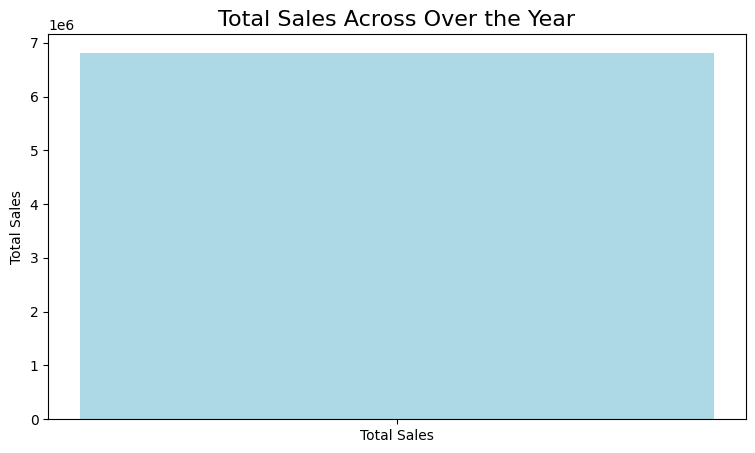

In [14]:
# Sum directly from df
total_sum_from_df = df['Total Product Charges'].sum()
print(f"Sum from df['Total Product Charges']: ₹{total_sum_from_df:,.2f}")

# Plot the total sales (single bar)
plt.figure(figsize=(9,5))
plt.bar(['Total Sales'], [total_sum_from_df], color='lightblue',width=0.4)
plt.ylabel('Total Sales')

plt.title('Total Sales Across Over the Year',fontsize=16)
plt.show()

Top Months by Sales:
   Month Name  Total Product Charges
7       March              630260.21
8         May              617927.99
3    February              600523.97
6        June              595118.78
11  September              589859.14
5        July              581592.87
10    October              575904.72
1      August              572166.70
9    November              566630.25
4     January              525764.25
0       April              487744.45
2    December              473483.56


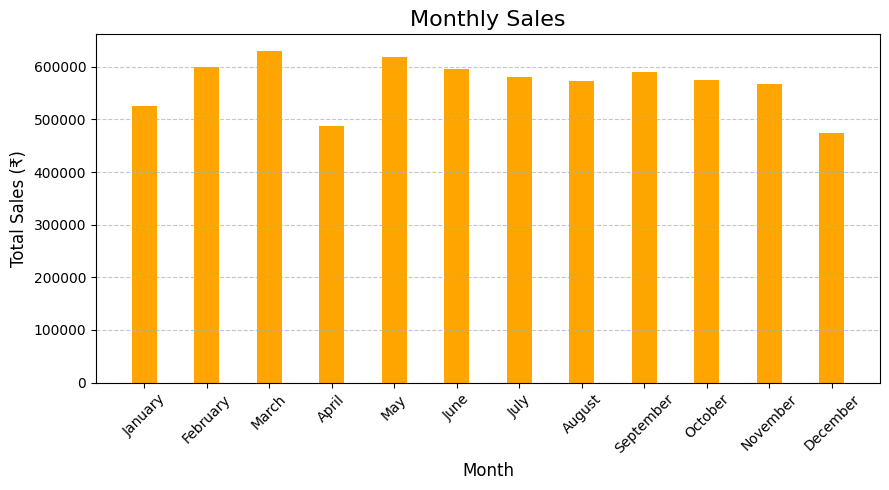

In [15]:
df['Year-Month'] = df['Order Date'].dt.to_period('M')
df['Month Name'] = df['Order Date'].dt.strftime('%B')

# Group by Month Name and calculate the total sales across all years
monthly_sales = df.groupby('Month Name')['Total Product Charges'].sum().reset_index()

# Sort months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales['Month Name'] = pd.Categorical(monthly_sales['Month Name'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('Month Name')

# Print top months by sales
top_months = monthly_sales.sort_values(by='Total Product Charges', ascending=False).head(12)
print("Top Months by Sales:")
print(top_months)

# Plot the data
plt.figure(figsize=(9, 5))
plt.bar(monthly_sales['Month Name'], monthly_sales['Total Product Charges'], color='orange', width=0.4)

# Add labels, title, and formatting
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (₹)', fontsize=12)
plt.title('Monthly Sales', fontsize=16)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()


In [16]:
print(df["Order Date"].value_counts().sum())
print(df["Order ID"].value_counts().sum())
print(df["Customer Name"].value_counts().sum())
print(df["Address"].value_counts().sum())
print(df["Products"].value_counts().sum())
print(df["Qty"].value_counts().sum())
print(df["Total Product Charges"].value_counts().sum())

9423
9419
9409
9418
9419
9334
9366


In [17]:
#check for null/nan values.
print(df['Qty'].isna().sum())
print(df['Total Product Charges'].isna().sum())  

89
57


In [18]:
#handle/fill null/nan values.

df['Qty'].fillna(df['Qty'].mode()[0], inplace=True)
df['Total Product Charges'].fillna(df['Total Product Charges'].median())

0        580.00
1        580.00
2        290.00
3        580.00
4        290.00
         ...   
9418    1207.63
9419     540.68
9420     576.27
9421     591.53
9422    1516.95
Name: Total Product Charges, Length: 9423, dtype: float64

In [19]:
print(df['Qty'].isna().sum())
print(df['Total Product Charges'].isna().sum())  

0
57


In [20]:
print(df[df['Total Product Charges']<0])  #very less negative values are present, convert it to default.
df['Total Product Charges'] = df['Total Product Charges'].apply(lambda x: max(x, 0))

              Order Date             Order ID Customer Name  \
4971 2024-07-01 00:00:00  402-1984216-7274730      Gayathri   
4987 2024-09-01 00:00:00  402-5488767-9412331         Biswa   
5026 2024-09-10 08:32:00  408-2693801-8585154           Sam   
5034 2024-08-11 16:00:00  406-7624447-6269133      Sarathak   

                                                Address  \
4971  No.33, Thembavani Street, Sri Sakti Nagar, Ann...   
4987  101/12 Art brute\n Auroville Main Road\n Aurov...   
5026  20A, Perumal Kovil street, vallioor, Tirunelve...   
5034  AQ 06 second floor sector 81, BPTP Park 81, Fa...   

                                               Products  Qty  \
4971  Gloss and Swipe N Shine\n Gloss, Glow, Flash\n...  8.0   
4987                Parryware Cascade Toilet Seat Cover  1.0   
5026                            Gloss, Glow, Shower Pro  2.0   
5034                    Parryware Common Inlet Assembly  2.0   

      Total Product Charges Year-Month Month Name  
4971           

In [21]:
#PRODUCT ANALYSIS.

df['Products'].value_counts()

Products
Glow - 2 Nos                   1516
Smartflush Citrus - 1 No        803
Smartflush Citrus               697
Gloss - 2 Nos                   677
Smartflush Aqua                 599
                               ... 
Pruno Swan Neck Pillar Cock       1
Claret Pillar cock                1
Slimline Tiger rubber kit         1
Cascade outlet assembly           1
Aquasot 16                        1
Name: count, Length: 692, dtype: int64

In [22]:
#cleaning product names as they are mixed with qty and address inbtwn.

import re

places = ['Chennai', 'Tamil Nadu', 'Bengaluru','Hyderabad', 'Delhi', 'Kolkata', 
               'Mumbai', 'Pune', 'Lucknow', 'Tripura', 'Jammu & Kashmir' ]

def clean_product(prod):
    if isinstance(prod,str):
        prod = re.sub(r'\s*-\s*\d+\s*(Nos|L|pieces|g|kg|ml|liters|units)?', '', prod, flags=re.IGNORECASE)
        prod = re.sub(r'\s+', ' ', prod).strip()

        if any(place.lower() in prod.lower() for place in places):
            return None
        return prod.strip()
    return None

df['Products'] = df['Products'].apply(clean_product)
df['Products'].fillna('Unknown')
print(df.head())

  Order Date             Order ID Customer Name                  Address  \
0 2024-01-01  404-2706690-0907523    R. Subbiah             Chennai - 91   
1 2024-01-01  404-6556614-7753950          Gail  Vijayawada, AP - 520010   
2 2024-01-01  403-3751965-0097158      Surendra     Madurai, TN - 625007   
3 2024-01-01  403-3760991-7970748         Sudip     Kolkata, WB - 700094   
4 2024-02-01  171-8928455-1097123       Brijesh             Chennai - 56   

              Products  Qty  Total Product Charges Year-Month Month Name  
0    Smartflush Citrus  2.0                  580.0    2024-01    January  
1    Smartflush Citrus  2.0                  580.0    2024-01    January  
2  Smartflush CitrusNo  1.0                  290.0    2024-01    January  
3    Smartflush Citrus  2.0                  580.0    2024-01    January  
4  Smartflush CitrusNo  1.0                  290.0    2024-02   February  


In [23]:
df['Products'].value_counts()

Products
Glow                                   1863
Smartflush Citrus                      1237
Smartflush CitrusNo                     803
Smartflush Aqua                         782
Gloss                                   764
                                       ... 
Floorclean SL 1L Glow                     1
Sanclean Pro Swipe N Shine and Glow       1
Pluto overhead shower                     1
38mm Knob Assembly Solid SC Hinges        1
Smartflush AquaNo Smartflush Citrus       1
Name: count, Length: 564, dtype: int64

Products
Glow                       1863
Smartflush Citrus          1237
Smartflush CitrusNo         803
Smartflush Aqua             782
Gloss                       764
Standard Seat Cover         301
Smartflush Mystic           225
Smartflush AquaNo           151
Slimline Inlet Assembly     134
Gloss, Glow, Shower Pro     133
Name: count, dtype: int64


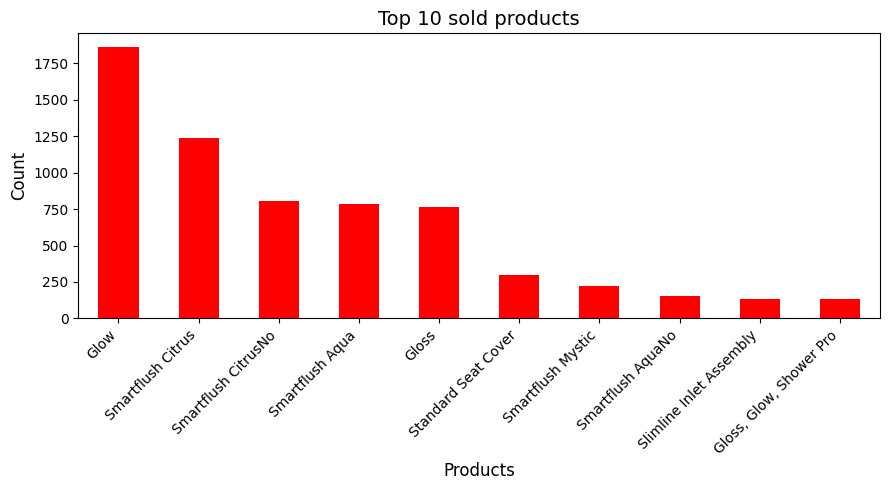

In [24]:
#Top 10 frequently bought products.
import matplotlib.pyplot as plt
product_count = df['Products'].value_counts()

top_n = 10
top_products = product_count.head(top_n)
print(top_products)
plt.figure(figsize=(9,5))
top_products.plot(kind='bar', color='red')
plt.title(f"Top {top_n} sold products", fontsize=14)
plt.xlabel("Products", fontsize =12)
plt.ylabel("Count",fontsize =12)
plt.xticks(rotation=45, ha='right',fontsize=10)
plt.tight_layout()
plt.show()

                             Total Product Charges
Products                                          
Glow                                    1077433.52
Smartflush Citrus                        753581.12
Aquasoft 30                              521145.03
Smartflush Aqua                          403702.76
Gloss                                    292268.83
Standard Seat Cover                      286958.24
Smartflush CitrusNo                      256087.11
Aquasoft 16                              224969.76
Aquasoft 12                              166204.80
Verve Soft Close Seat Cover              115498.77


<Figure size 900x500 with 0 Axes>

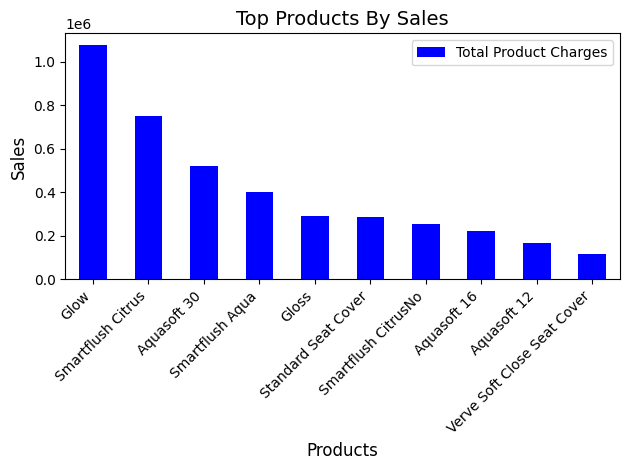

In [25]:
product_sales = df.groupby('Products').agg({'Total Product Charges':'sum'})
top_product_by_sales = product_sales.sort_values(by='Total Product Charges',ascending=False).head(10)
print(top_product_by_sales)
plt.figure(figsize=(9,5))
top_product_by_sales.plot(kind='bar', color='blue')
plt.title(f"Top Products By Sales", fontsize=14)
plt.xlabel("Products", fontsize =12)
plt.ylabel("Sales",fontsize =12)
plt.xticks(rotation=45, ha='right',fontsize=10)
plt.tight_layout()
plt.show()

In [26]:
print(df.columns)

Index(['Order Date', 'Order ID', 'Customer Name', 'Address', 'Products', 'Qty',
       'Total Product Charges', 'Year-Month', 'Month Name'],
      dtype='object')


                             Total Sales  Quantity Sold
Products                                               
Glow                          1077433.52         4492.0
Smartflush Citrus              753581.12         2596.0
Aquasoft 30                    521145.03           27.0
Smartflush Aqua                403702.76         1301.0
Gloss                          292268.83         1717.0
Standard Seat Cover            286958.24          344.0
Smartflush CitrusNo            256087.11          803.0
Aquasoft 16                    224969.76           43.0
Aquasoft 12                    166204.80           76.0
Verve Soft Close Seat Cover    115498.77           35.0
                                 Total Sales  Quantity Sold
Products                                                   
Glow                              1077433.52         4492.0
Smartflush Citrus                  753581.12         2596.0
Gloss                              292268.83         1717.0
Smartflush Aqua             

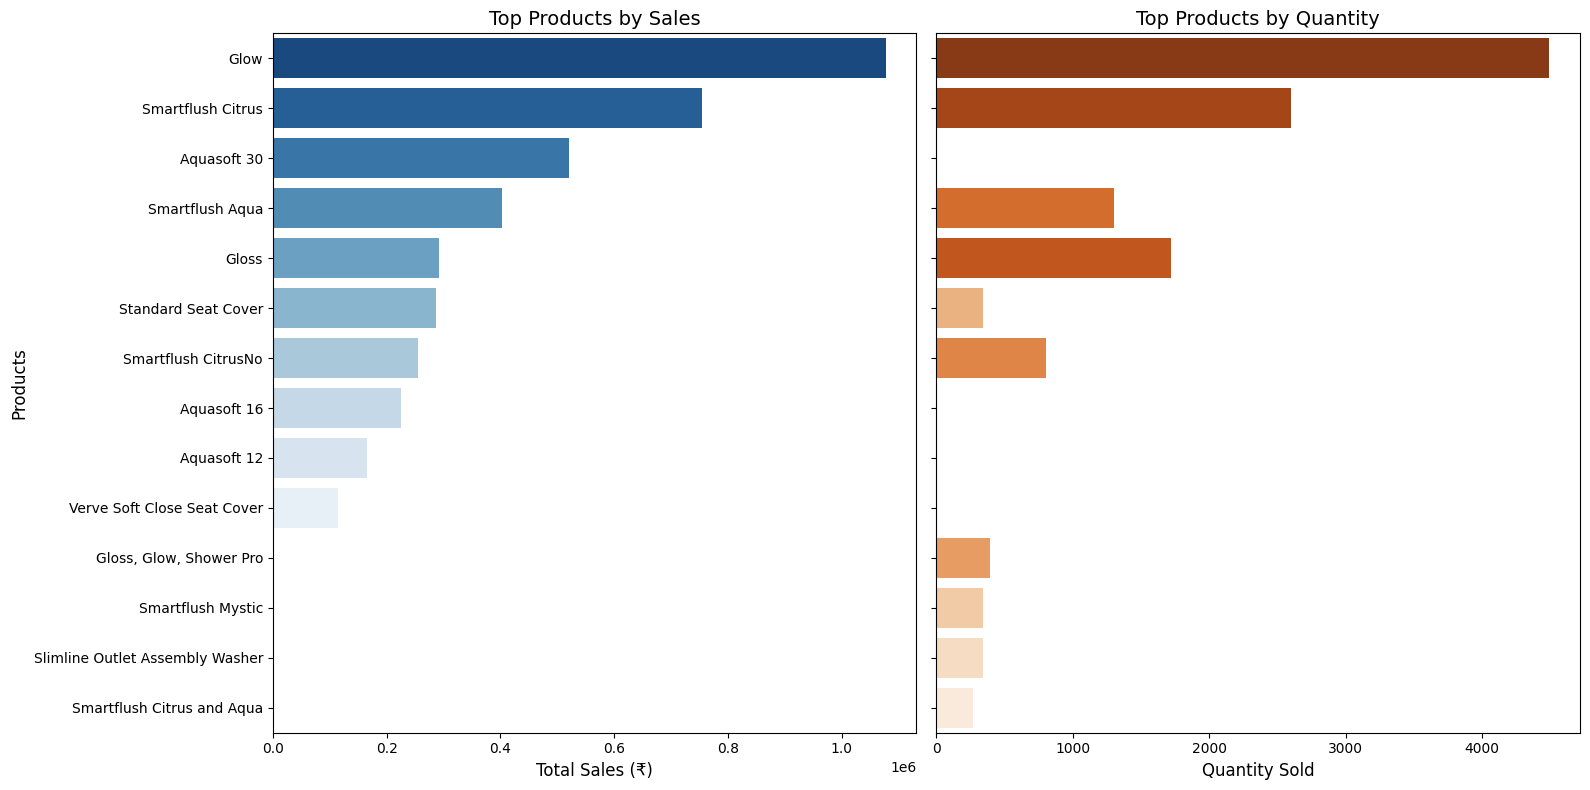

In [27]:
product_anal = df.groupby('Products').agg({
    'Total Product Charges' : 'sum',
    'Qty' : 'sum'
}).rename(columns={
    'Total Product Charges' : 'Total Sales',
    'Qty' : 'Quantity Sold' })

top_sales_products = product_anal.sort_values(by='Total Sales', ascending=False).head(10)
top_quantity_products = product_anal.sort_values(by='Quantity Sold', ascending=False).head(10)
print(top_sales_products)
print(top_quantity_products)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
sns.barplot(x='Total Sales',
            y=top_sales_products.index,
            data=top_sales_products.reset_index(),
            palette='Blues_r',
            hue='Products',
            ax=axes[0]
           )
axes[0].set_title('Top Products by Sales', fontsize=14)
axes[0].set_xlabel('Total Sales (₹)', fontsize=12)
axes[0].set_ylabel('Products', fontsize=12)

sns.barplot(
    x='Quantity Sold', 
    y=top_quantity_products.index,
    data=top_quantity_products.reset_index(),
    palette='Oranges_r',
    hue='Products',
    ax=axes[1]
)
axes[1].set_title('Top Products by Quantity', fontsize=14)
axes[1].set_xlabel('Quantity Sold', fontsize=12)
axes[1].set_ylabel('Products', fontsize=12)

plt.tight_layout()
plt.show()

In [28]:
import re
import pandas as pd

# Dictionary to map abbreviations and variants to full state names
state_mapping = {
    'KA': 'Karnataka',
    'WB': 'West Bengal',
    'MH': 'Maharashtra',
    'J&K': 'Jammu & Kashmir',
    'TN': 'Tamil Nadu',
    'UP': 'Uttar Pradesh',
    'AP': 'Andhra Pradesh',
    'GJ': 'Gujarat',
    'DL': 'Delhi',
    'HR': 'Haryana',
    'BR': 'Bihar',
    'RJ': 'Rajasthan',
    'MP': 'Madhya Pradesh',
    'PB': 'Punjab',
    'KL': 'Kerala',
    'OR': 'Odisha',
    'TS': 'Telangana',
    'JK': 'Jammu & Kashmir',
    'Ch': 'Chennai',
    'Chh': 'Chhattisgarh',
    'Bengaluru': 'Karnataka',
    'Kolkata': 'West Bengal',
    'Mumbai': 'Maharashtra',
    'Chennai': 'Tamil Nadu'
}

# Function to extract state or district
def extract_state(address):
    if not isinstance(address, str):
        return 'Unknown'  # Handle NaN or non-string values

    # Convert address to lowercase for matching
    address = address.lower()

    # Check for state abbreviations (e.g., TN, KA)
    abbrev_match = re.search(r'\b[a-zA-Z]{2}\b', address)
    if abbrev_match:
        abbrev = abbrev_match.group(0).upper()
        if abbrev in state_mapping:
            return state_mapping[abbrev]

    # Check for full state names in the address
    for state, full_name in state_mapping.items():
        if state.lower() in address or full_name.lower() in address:
            return full_name

    # Fallback: Extract the last part of the address
    parts = address.split(',')
    if parts:
        return parts[-1].strip().title()

    return 'Unknown'

# Apply the function to the 'Address' column
df['State/District'] = df['Address'].apply(extract_state)

# Display the updated DataFrame
print(df[['Address', 'State/District']].head())


                   Address  State/District
0             Chennai - 91         Chennai
1  Vijayawada, AP - 520010  Andhra Pradesh
2     Madurai, TN - 625007      Tamil Nadu
3     Kolkata, WB - 700094     West Bengal
4             Chennai - 56         Chennai


In [29]:
odisha_count = df[df['State/District'] == 'Chennai'].shape[0]
print(odisha_count)

1603


In [30]:
print(df[['Address', 'State/District']].head(10))
print(df['State/District'].isnull().sum())  # Check for any missing values
print(df['State/District'].value_counts())

                   Address  State/District
0             Chennai - 91         Chennai
1  Vijayawada, AP - 520010  Andhra Pradesh
2     Madurai, TN - 625007      Tamil Nadu
3     Kolkata, WB - 700094     West Bengal
4             Chennai - 56         Chennai
5   Bengaluru, KA - 560098       Karnataka
6       New Delhi - 110053           Delhi
7       Bengaluru, KA - 61       Karnataka
8      Mysuru, KA - 570030       Karnataka
9   Bengaluru, KA - 560068       Karnataka
0
State/District
Karnataka             2134
Chennai               1603
Andhra Pradesh         732
Tamil Nadu             695
Maharashtra            596
                      ... 
Ayanavaram               1
Paravai                  1
Dasanaikenpatty          1
Jharkhand - 831014       1
Koothanallur             1
Name: count, Length: 330, dtype: int64


In [31]:
#df.head(10)

In [32]:
odisha_count = df[df['State/District'] == 'Delhi'].shape[0]
print(odisha_count)

180


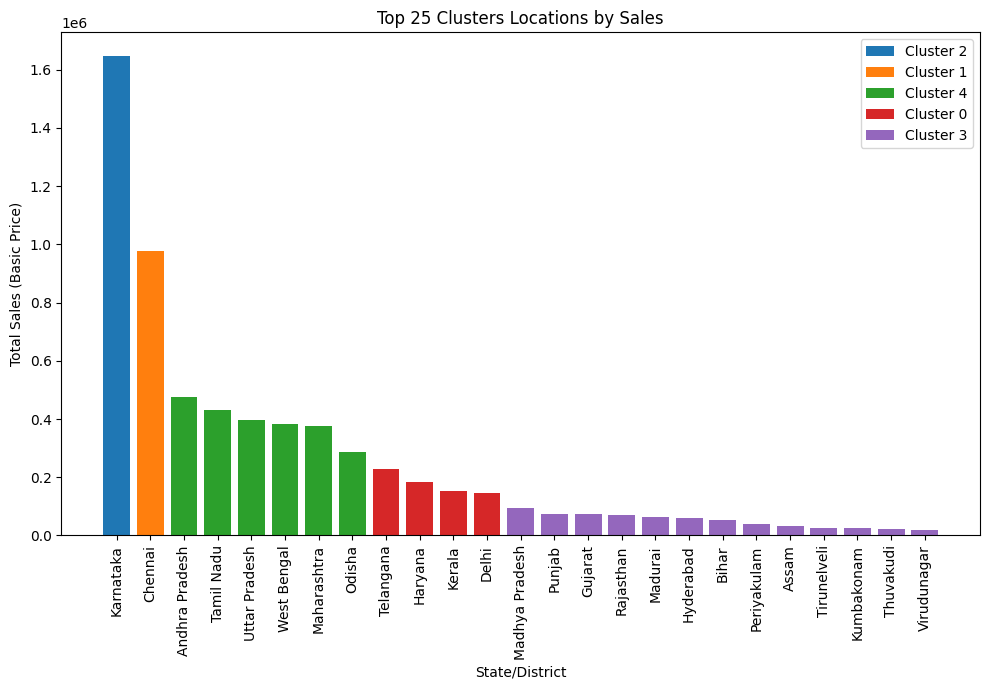

In [33]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Ensure numeric data for clustering
df['Total Product Charges'] = pd.to_numeric(df['Total Product Charges'], errors='coerce')
df.fillna({'Total Product Charges': 0}, inplace=True)

# Group by 'State/District' and calculate total sales
state_sales = df.groupby('State/District')['Total Product Charges'].sum().reset_index()

# Select top 100 districts by total sales
state_sales = state_sales.sort_values(by='Total Product Charges', ascending=False).head(25)

# Standardize sales data for clustering
scaler = StandardScaler()
state_sales['Standardized Sales'] = scaler.fit_transform(state_sales[['Total Product Charges']])

# Perform K-means clustering
kmeans = KMeans(n_clusters=5, random_state=42)
state_sales['Cluster'] = kmeans.fit_predict(state_sales[['Standardized Sales']])

# Visualize Clusters
fig1 = plt.figure(figsize=(10, 7))
for cluster in state_sales['Cluster'].unique():
    cluster_data = state_sales[state_sales['Cluster'] == cluster]
    plt.bar(cluster_data['State/District'], cluster_data['Total Product Charges'], label=f'Cluster {cluster}')

plt.title('Top 25 Clusters Locations by Sales')
plt.xlabel('State/District')
plt.ylabel('Total Sales (Basic Price)')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()



In [34]:
# Display cluster summaries
for cluster in state_sales['Cluster'].unique():
    cluster_data = state_sales[state_sales['Cluster'] == cluster]
    print(f"Cluster {cluster}:")
    print(f"  Total Districts: {len(cluster_data)}")
    print(f"  Average Sales: {cluster_data['Total Product Charges'].mean():.2f}")
    print(f"  Districts in this cluster: {', '.join(cluster_data['State/District'].values)}\n")


Cluster 2:
  Total Districts: 1
  Average Sales: 1645667.83
  Districts in this cluster: Karnataka

Cluster 1:
  Total Districts: 1
  Average Sales: 976364.79
  Districts in this cluster: Chennai

Cluster 4:
  Total Districts: 6
  Average Sales: 390791.03
  Districts in this cluster: Andhra Pradesh, Tamil Nadu, Uttar Pradesh, West Bengal, Maharashtra, Odisha

Cluster 0:
  Total Districts: 4
  Average Sales: 177231.45
  Districts in this cluster: Telangana, Haryana, Kerala, Delhi

Cluster 3:
  Total Districts: 13
  Average Sales: 49947.52
  Districts in this cluster: Madhya Pradesh, Punjab, Gujarat, Rajasthan, Madurai, Hyderabad, Bihar, Periyakulam, Assam, Tirunelveli, Kumbakonam, Thuvakudi, Virudunagar



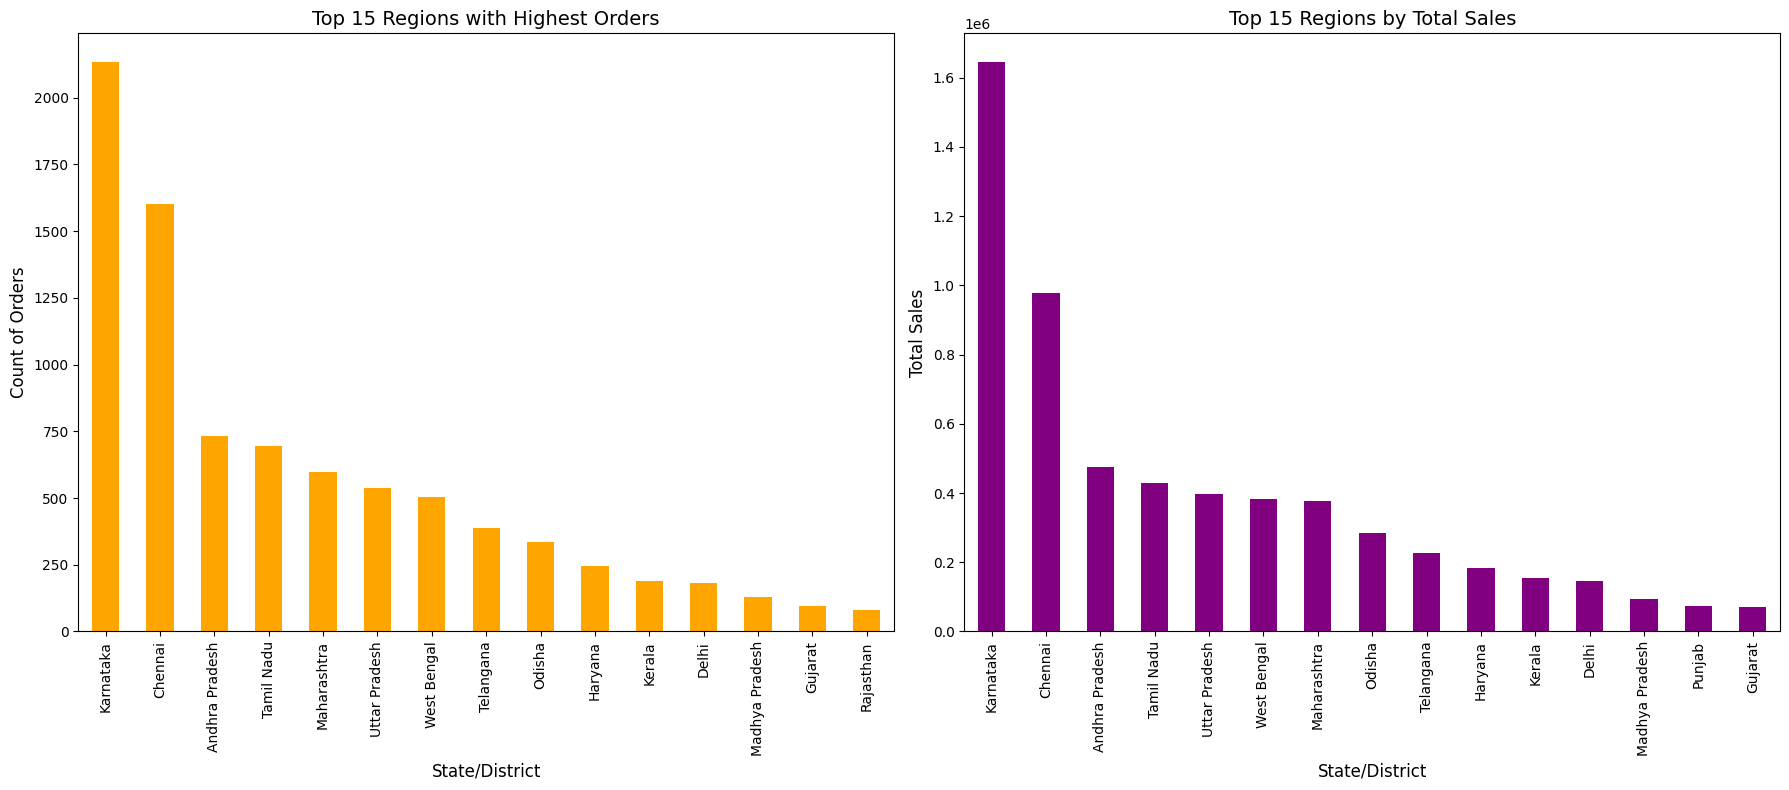

In [35]:
import matplotlib.pyplot as plt

# Count the number of occurrences in each region (order count)
count_by_region = df['State/District'].value_counts()

# Group by 'State/District' and sum total sales
sales_by_region = df.groupby('State/District')['Total Product Charges'].sum()

# Select top 10 or 15 regions based on count and sales
top_n = 15  # Change this to 10 or 15 as needed
top_regions_count = count_by_region.head(top_n)
top_regions_sales = sales_by_region.sort_values(ascending=False).head(top_n)

# Create subplots with two side-by-side plots
fig17, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot count distribution
top_regions_count.plot(kind='bar', ax=axes[0], color='orange')
axes[0].set_title(f'Top {top_n} Regions with Highest Orders', fontsize=14)
axes[0].set_xlabel('State/District', fontsize=12)
axes[0].set_ylabel('Count of Orders', fontsize=12)

# Plot sales distribution
top_regions_sales.plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_title(f'Top {top_n} Regions by Total Sales', fontsize=14)
axes[1].set_xlabel('State/District', fontsize=12)
axes[1].set_ylabel('Total Sales', fontsize=12)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [36]:
#Sales trends
#sales trend over the year

In [37]:
# # Ensure all months are present in the plot
# all_months = pd.date_range(start='1/1/2024', end='12/31/2024', freq='ME').strftime('%B')  # Adjust year range
# sales_trend_over_the_year = sales_trend_over_the_year.reindex(all_months, fill_value=0)


Text(0.5, 1.0, 'Sales Trend Over The Year')

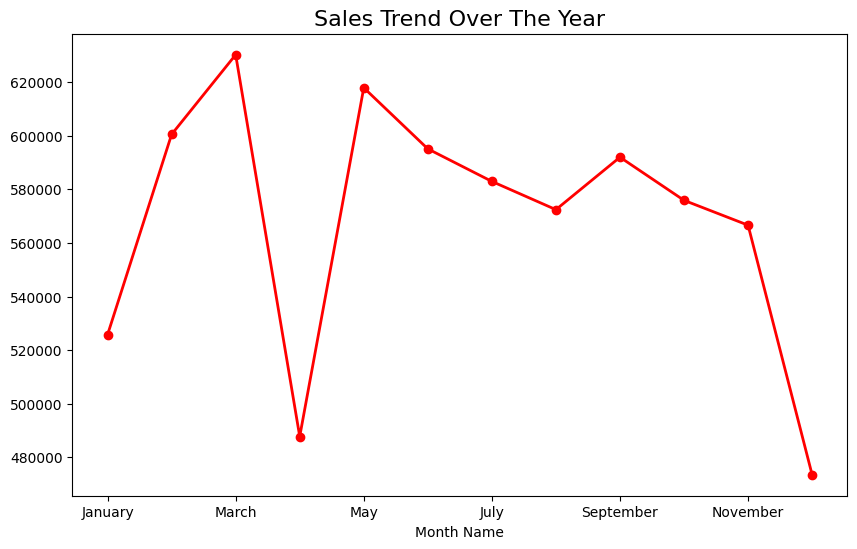

In [38]:
# Define the correct order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['Month Name'] = pd.Categorical(df['Month Name'], categories=month_order, ordered=True)

# Now group and plot
plt.figure(figsize=(10,6))
sales_trend_over_the_year = df.groupby('Month Name')['Total Product Charges'].sum()
sales_trend_over_the_year.plot(kind='line', color='red', marker='o', linewidth=2)
plt.title('Sales Trend Over The Year',fontsize=16)

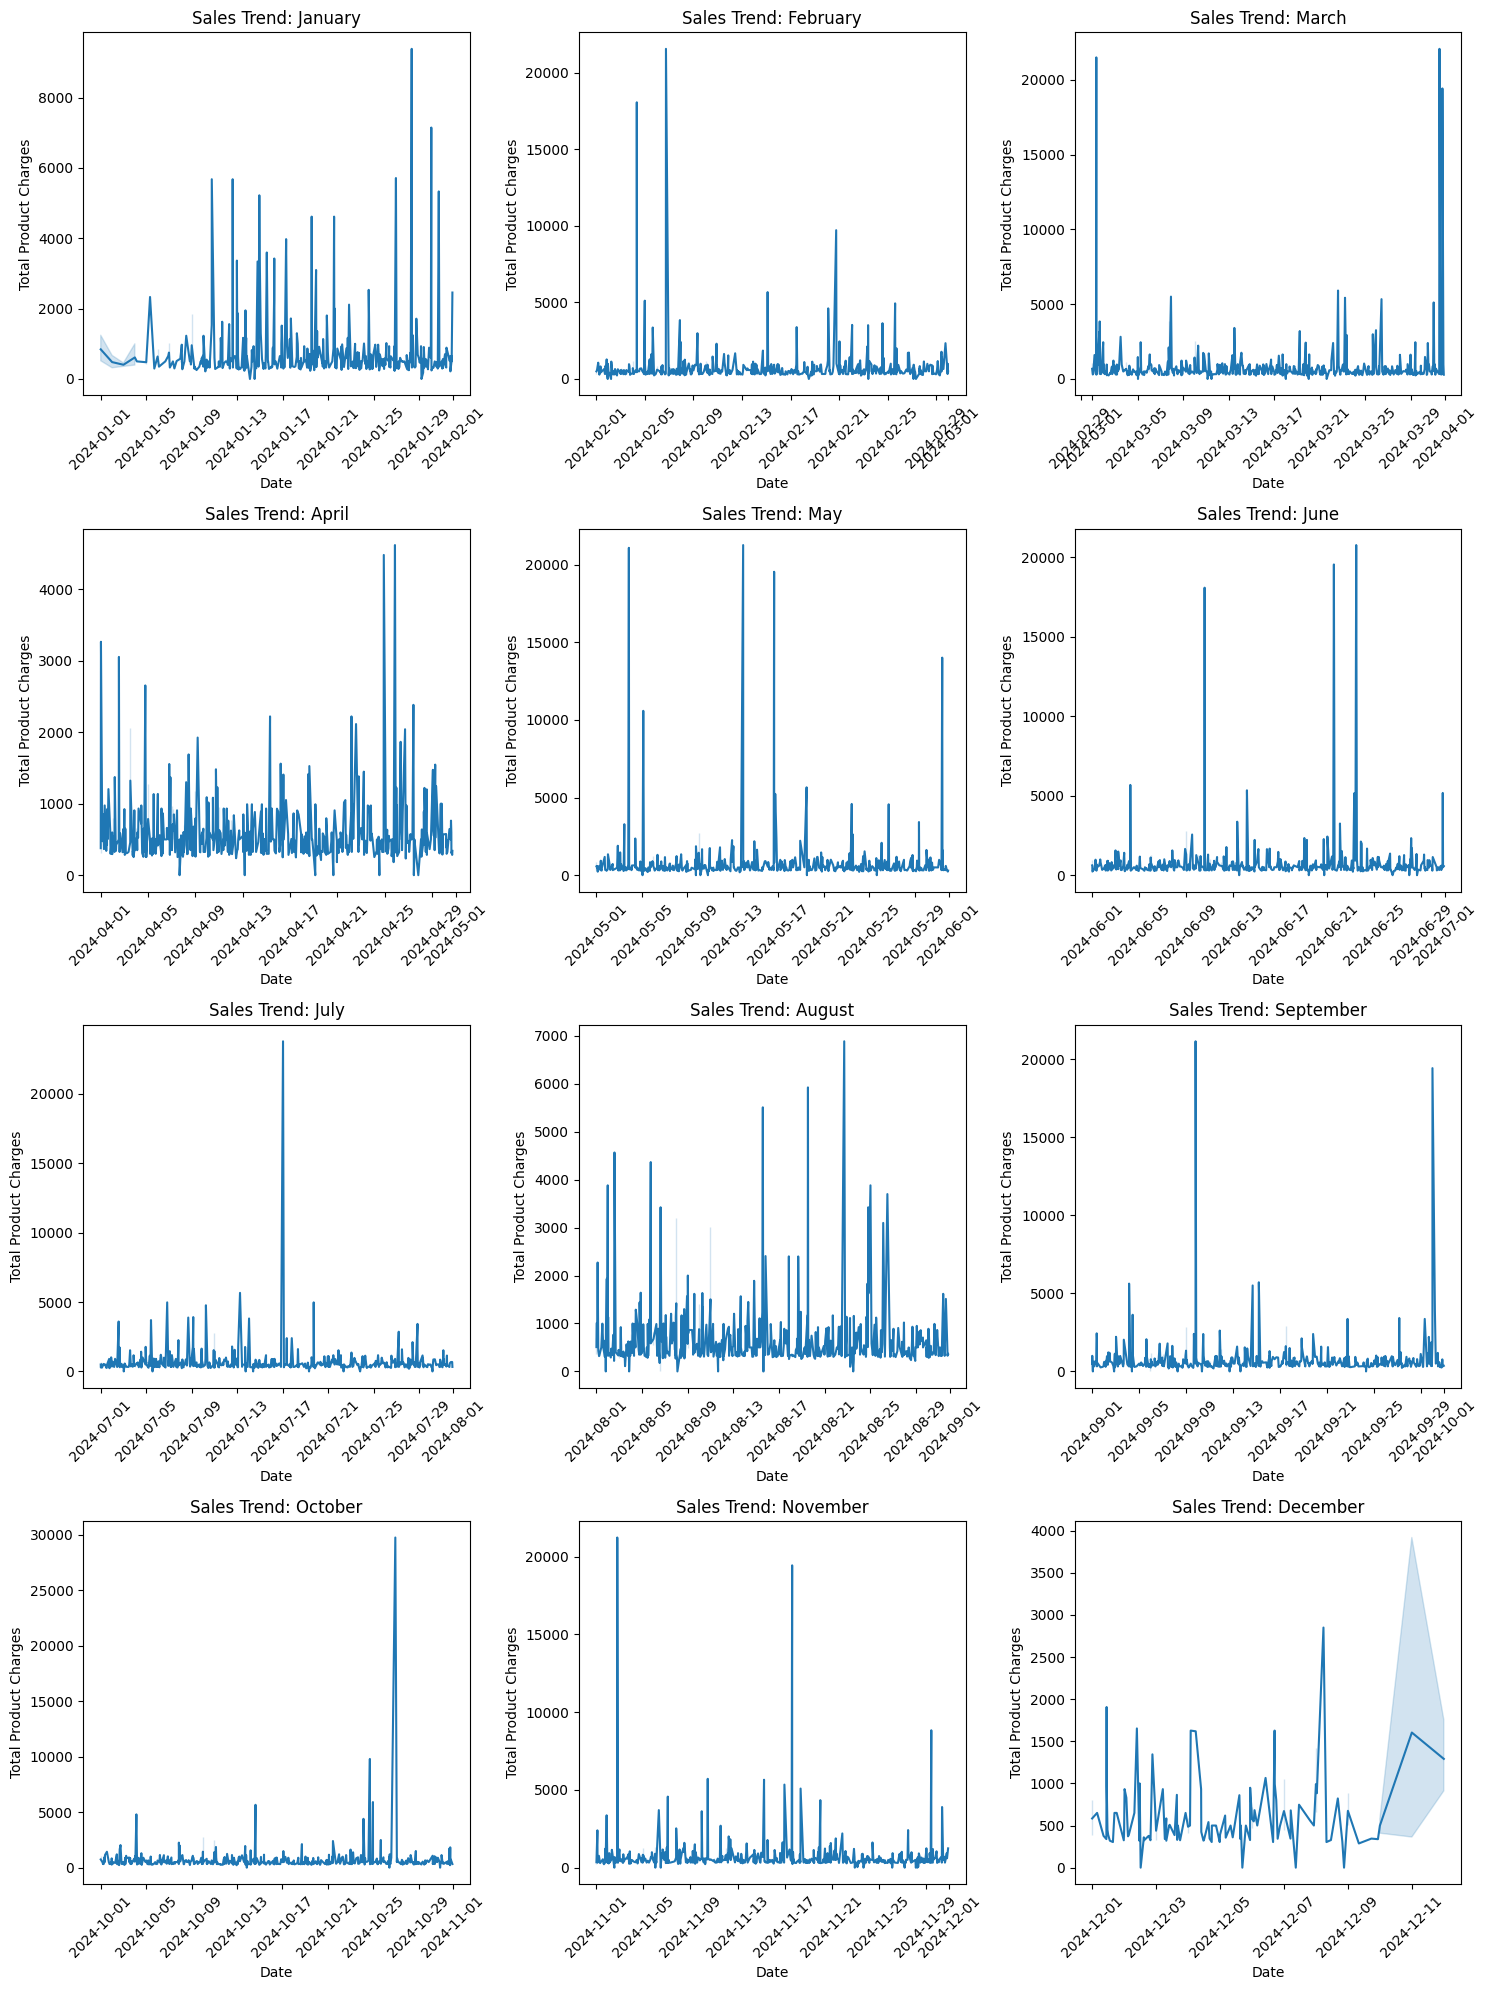

In [39]:
#sales trend over each month

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['Month Name'] = pd.Categorical(df['Month Name'], categories=month_order, ordered=True)

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20))
axes = axes.flatten()


for i, month in enumerate(month_order):
    monthly_data = df[df['Month Name'] == month]
    sns.lineplot(x="Order Date", y="Total Product Charges", data=monthly_data, ax=axes[i])
    axes[i].set_title(f"Sales Trend: {month}", fontsize=12)
    axes[i].set_xlabel('Date', fontsize=10)
    axes[i].set_ylabel('Total Product Charges', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Sales by Day of the Week:
 Order Date
Monday        914273.36
Tuesday       861946.45
Wednesday     834693.78
Thursday     1195322.08
Friday        994459.40
Saturday      875803.76
Sunday       1144268.76
Name: Total Product Charges, dtype: float64


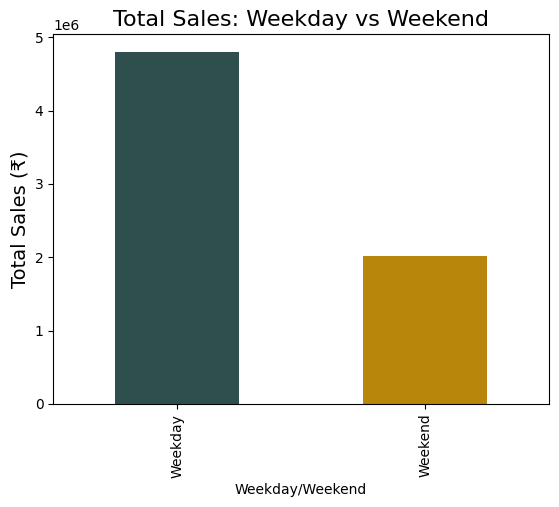

In [40]:
df['Weekday/Weekend'] = df['Order Date'].dt.weekday.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
sales_by_weekday_weekend = df.groupby('Weekday/Weekend')['Total Product Charges'].sum()

sales_by_day_of_week = df.groupby(df['Order Date'].dt.dayofweek)['Total Product Charges'].sum()

sales_by_day_of_week.index = sales_by_day_of_week.index.map({
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
})

print("Sales by Day of the Week:\n", sales_by_day_of_week)

sales_by_weekday_weekend.plot(kind='bar', color=['darkslategray', 'darkgoldenrod'])
plt.title('Total Sales: Weekday vs Weekend', fontsize=16)
plt.ylabel('Total Sales (₹)', fontsize=14)
plt.show()


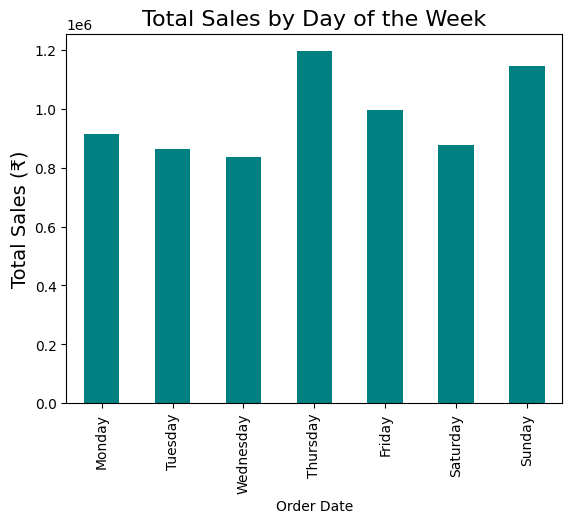

In [41]:
# Plot sales by each day of the week
sales_by_day_of_week.plot(kind='bar', color='teal')
plt.title('Total Sales by Day of the Week', fontsize=16)
plt.ylabel('Total Sales (₹)', fontsize=14)
plt.show()


   Year  Order ID
0  2024      9404


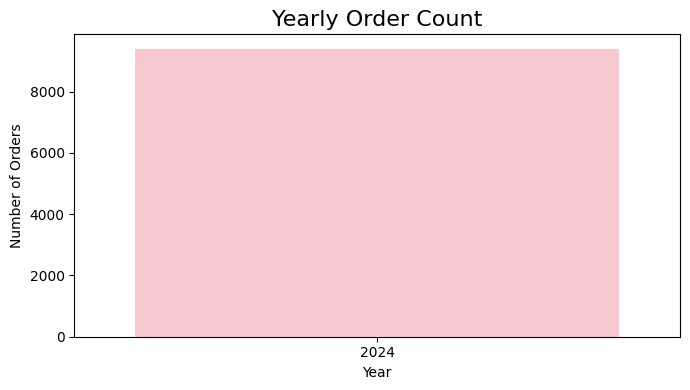

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

df['Year'] = df['Order Date'].dt.year

yearly_order = df.groupby('Year')['Order ID'].nunique().reset_index()

print(yearly_order)


plt.figure(figsize=(7, 4))
sns.barplot(x='Year', y='Order ID', data=yearly_order, color='pink')
plt.title('Yearly Order Count',fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


In [43]:
print(df['Order Date'])

0      2024-01-01
1      2024-01-01
2      2024-01-01
3      2024-01-01
4      2024-02-01
          ...    
9418   2024-12-12
9419   2024-12-12
9420   2024-12-12
9421   2024-12-12
9422   2024-12-12
Name: Order Date, Length: 9423, dtype: datetime64[ns]


   Month Name  Order ID
0     January       750
1    February       830
2       March       827
3       April       806
4         May       821
5        June       795
6        July       826
7      August       802
8   September       803
9     October       823
10   November       793
11   December       529


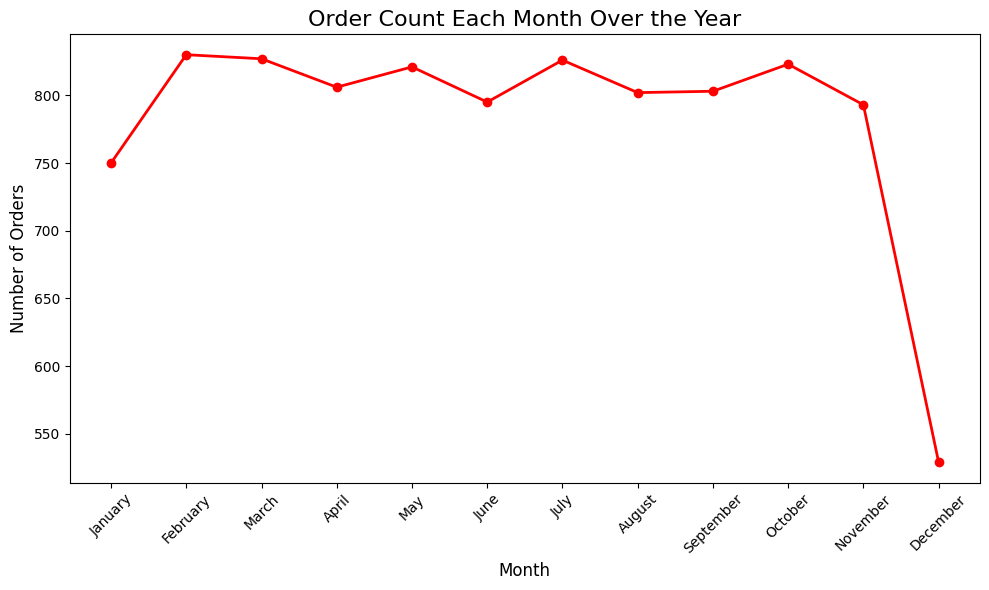

In [44]:
import matplotlib.pyplot as plt

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['Month Name'] = pd.Categorical(df['Month Name'], categories=month_order, ordered=True)

monthly_order_count = df.groupby('Month Name')['Order ID'].nunique().reset_index()
print(monthly_order_count)
plt.figure(figsize=(10, 6))
plt.plot(monthly_order_count['Month Name'], monthly_order_count['Order ID'], color='red', marker='o', linewidth=2)
plt.title('Order Count Each Month Over the Year', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


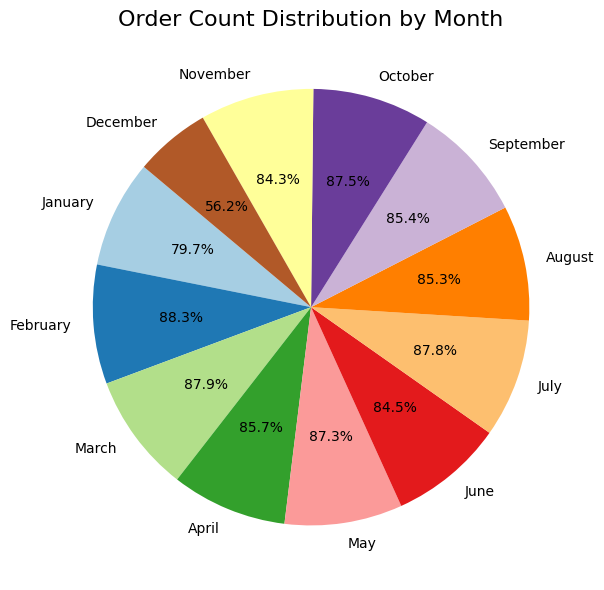

In [45]:
import matplotlib.pyplot as plt

monthly_order_count = df.groupby('Month Name')['Order ID'].nunique().reset_index()

plt.figure(figsize=(10,6))
plt.pie(monthly_order_count['Order ID'], labels=monthly_order_count['Month Name'], autopct=lambda p: f'{p*10:.1f}%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Order Count Distribution by Month', fontsize=16)
plt.tight_layout()
plt.show()


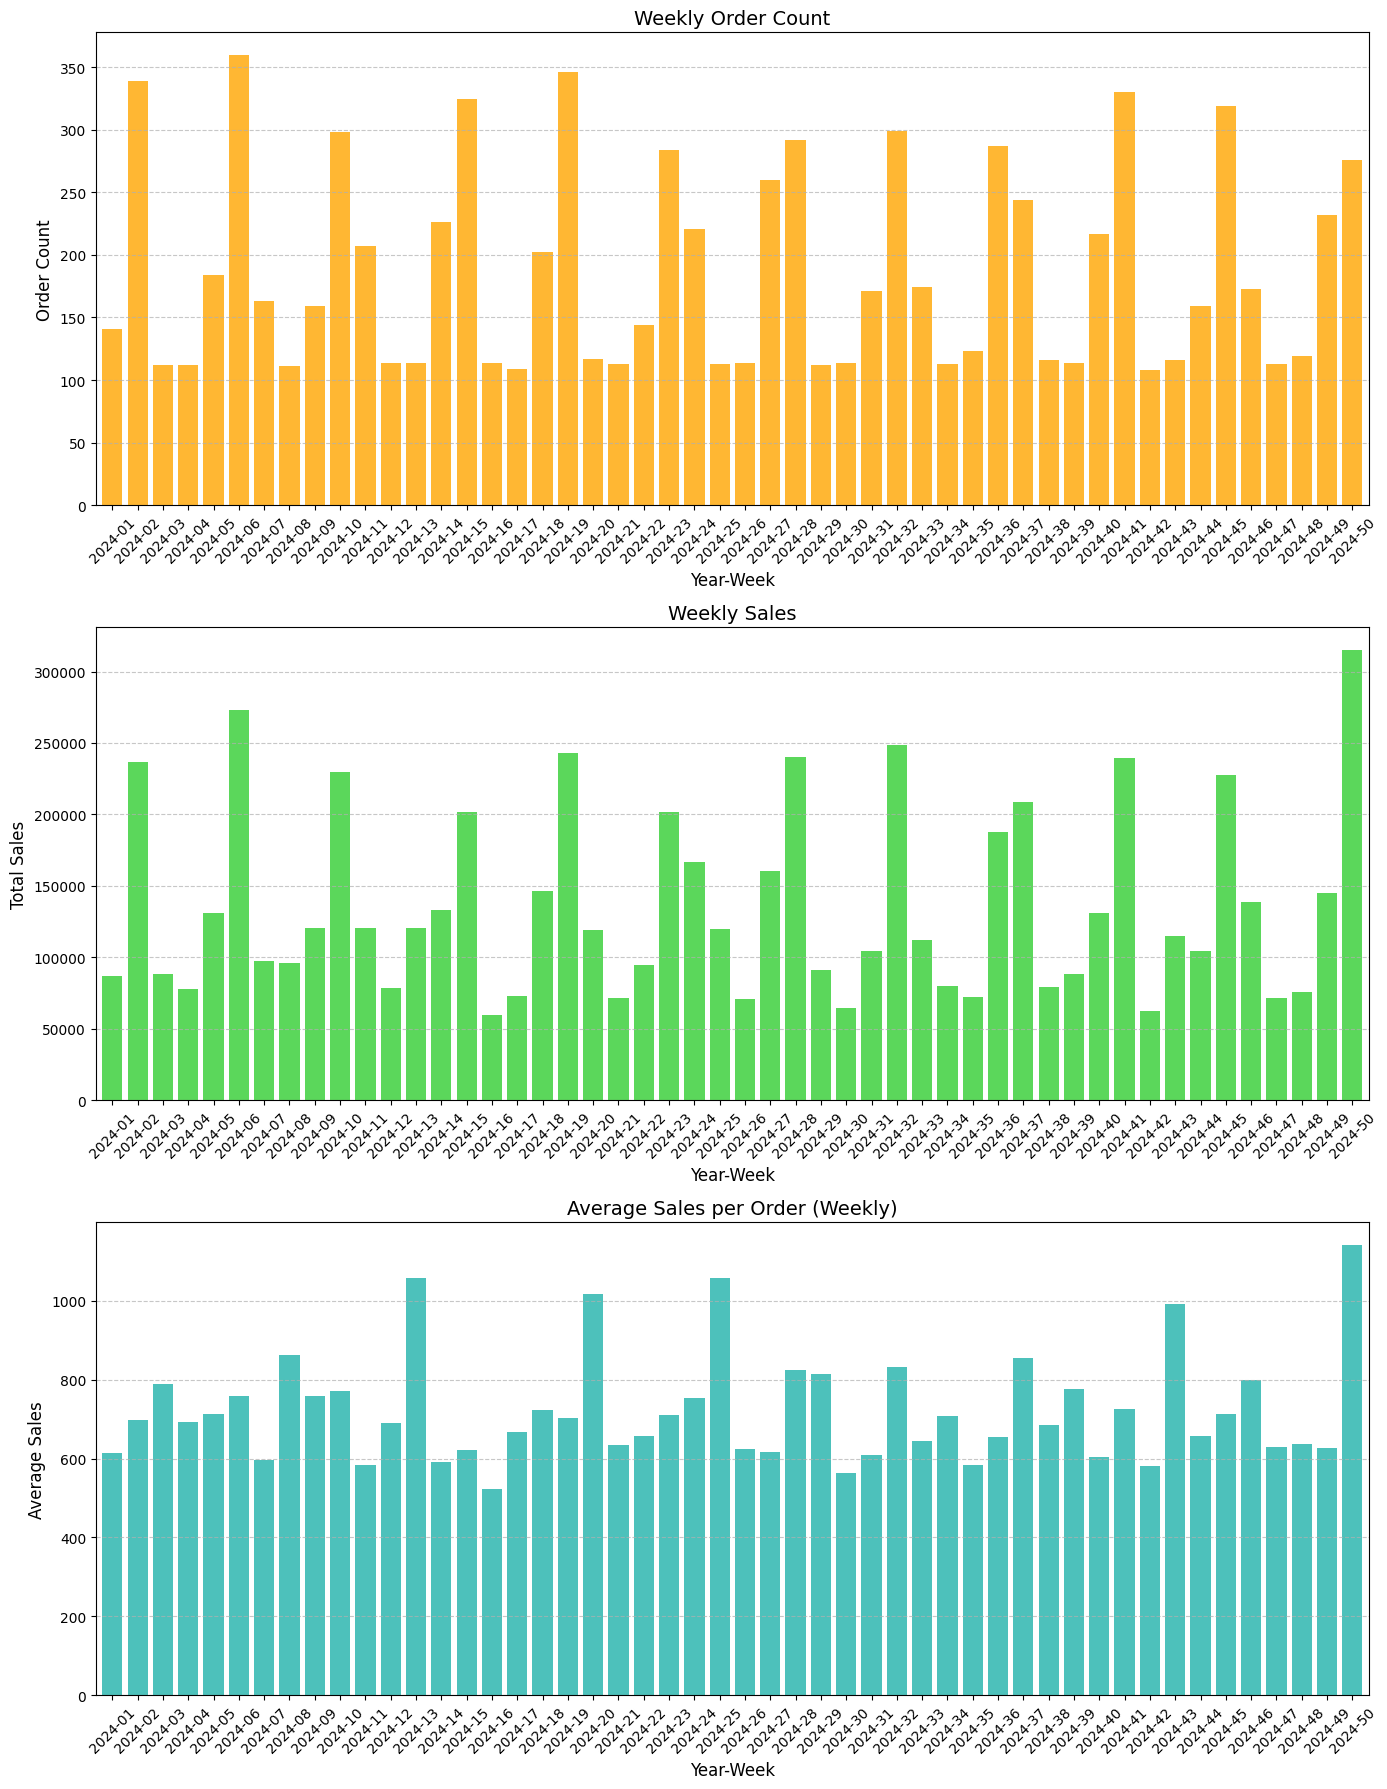

In [46]:
# Weekly order count
df['Year-week'] = df['Order Date'].dt.strftime('%Y-%W')
weekly_order_count = df.groupby('Year-week').size()

weekly_sales = df.groupby('Year-week')['Total Product Charges'].sum()

avg_sales_per_order = weekly_sales / weekly_order_count

plt.figure(figsize=(14, 18))


plt.subplot(3, 1, 1) 
weekly_order_count.plot(kind='bar', color='orange', alpha=0.8, width=0.8)
plt.title('Weekly Order Count', fontsize=14)
plt.xlabel('Year-Week', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(3, 1, 2)  
weekly_sales.plot(kind='bar', color='limegreen', alpha=0.8, width=0.8)
plt.title('Weekly Sales', fontsize=14)
plt.xlabel('Year-Week', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(3, 1, 3)  
avg_sales_per_order.plot(kind='bar', color='lightseagreen', alpha=0.8, width=0.8)
plt.title('Average Sales per Order (Weekly)', fontsize=14)
plt.xlabel('Year-Week', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Total Quantity Ordered Across All Years: 18968.0


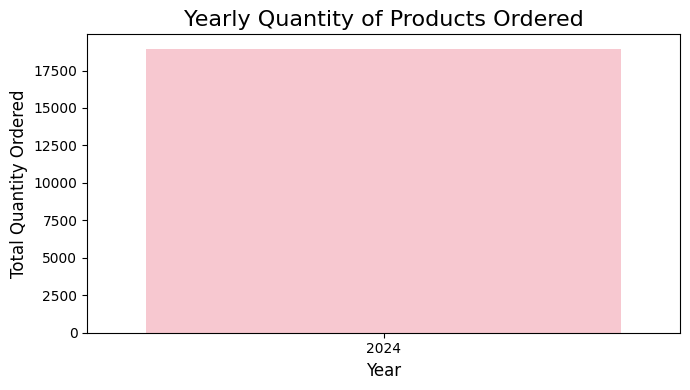

In [47]:
# Group by year and calculate the total quantity ordered
df['Year'] = df['Order Date'].dt.year
yearly_order = df.groupby('Year')['Qty'].sum().reset_index()
yearly_order.rename(columns={'Qty': 'total_quantity_ordered'}, inplace=True)

# Calculate the total quantity ordered across all years
total_quantity_ordered = df['Qty'].sum()
print(f"Total Quantity Ordered Across All Years: {total_quantity_ordered}")

# Plot yearly total quantity ordered
plt.figure(figsize=(7, 4))
sns.barplot(x='Year', y='total_quantity_ordered', data=yearly_order, color='pink')
plt.title('Yearly Quantity of Products Ordered', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Quantity Ordered', fontsize=12)
plt.tight_layout()
plt.show()


   Month Name     Qty
0     January  1506.0
1    February  1652.0
2       March  1679.0
3       April  1627.0
4         May  1652.0
5        June  1527.0
6        July  1602.0
7      August  1656.0
8   September  1594.0
9     October  1685.0
10   November  1639.0
11   December  1149.0


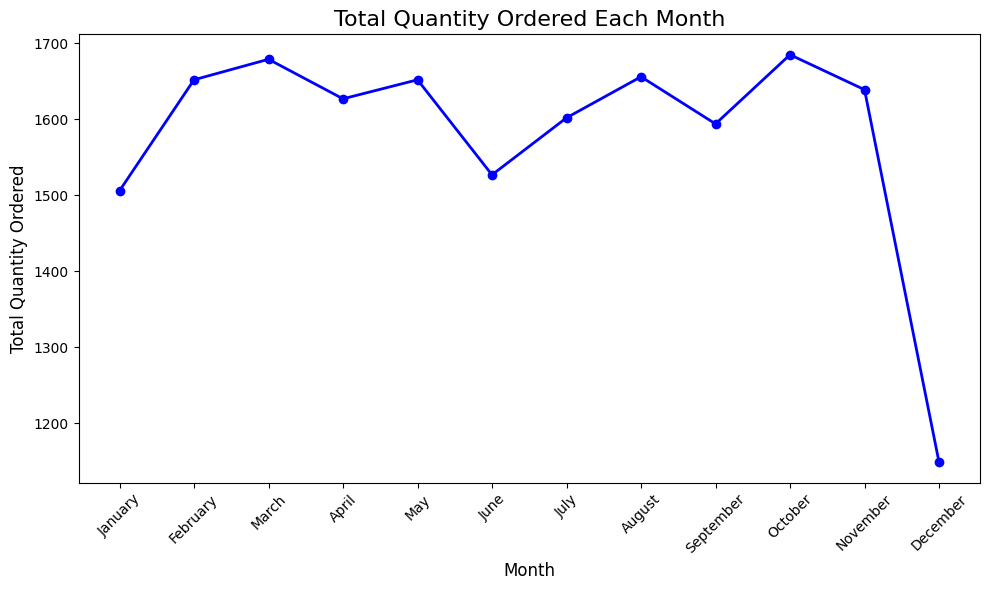

In [48]:
# Ensure months are ordered correctly
df['Month Name'] = pd.Categorical(df['Month Name'], categories=month_order, ordered=True)

# Group by Month and calculate total quantity
monthly_order_quantity = df.groupby('Month Name')['Qty'].sum().reset_index()

# Print the resulting DataFrame
print(monthly_order_quantity)

# Plot the total quantity ordered each month
plt.figure(figsize=(10, 6))
plt.plot(monthly_order_quantity['Month Name'], monthly_order_quantity['Qty'], color='blue', marker='o', linewidth=2)
plt.title('Total Quantity Ordered Each Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Quantity Ordered', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top customers who provide most sales over the year:

Customer Name
Sandeep            44764.72
Arun               44570.23
Sheik              38593.22
Arumugam           33246.42
Mahesh             29767.29
Deepak             29245.08
Senthil            28468.00
Rohit              27999.23
Saravanan          26097.68
Radhakrishnan      25758.73
Richa              25745.13
Subhash            25083.22
Wasim              24711.01
Abhishek           24569.39
Sailendra          23782.20
Vijay              23397.44
Sundarapandian     22962.71
Anand              22465.97
Jiss               22080.42
Ashish             21818.38
M                  21762.50
Ajeesh             21576.27
Nagendra           21262.71
Murali R           21220.34
Bhaskara           21152.54
Binu               21101.86
Puneeth            20952.20
Johnson            20897.88
Sabarish           20023.73
Hotel              19978.31
Subhashini         19932.20
Karthi             19766.95
Rajanikant         19542.37
Anmol    

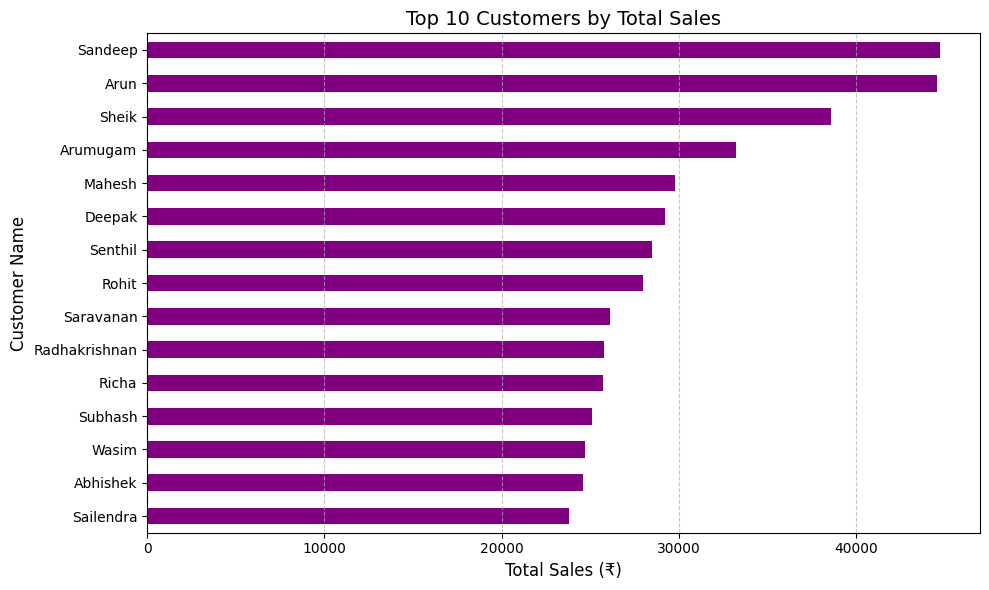

In [47]:
#Customer Analysis

top_15_customers = df.groupby('Customer Name')['Total Product Charges'].sum().sort_values(ascending=False).head(15)
top_customers = df.groupby('Customer Name')['Total Product Charges'].sum().sort_values(ascending=False)


plt.figure(figsize=(10, 6))
top_15_customers.plot(kind='barh', color='purple')
plt.title('Top 10 Customers by Total Sales', fontsize=14)
plt.xlabel('Total Sales (₹)', fontsize=12)
plt.ylabel('Customer Name', fontsize=12)

plt.gca().invert_yaxis() # Reverse the order of the y-axis to show the highest spender at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [66]:
print("Top customers who provide most sales over the year:\n")
print(top_customers.head(50))

Top customers who provide most sales over the year:

Customer Name
Sandeep            44764.72
Arun               44570.23
Sheik              38593.22
Arumugam           33246.42
Mahesh             29767.29
Deepak             29245.08
Senthil            28468.00
Rohit              27999.23
Saravanan          26097.68
Radhakrishnan      25758.73
Richa              25745.13
Subhash            25083.22
Wasim              24711.01
Abhishek           24569.39
Sailendra          23782.20
Vijay              23397.44
Sundarapandian     22962.71
Anand              22465.97
Jiss               22080.42
Ashish             21818.38
M                  21762.50
Ajeesh             21576.27
Nagendra           21262.71
Murali R           21220.34
Bhaskara           21152.54
Binu               21101.86
Puneeth            20952.20
Johnson            20897.88
Sabarish           20023.73
Hotel              19978.31
Subhashini         19932.20
Karthi             19766.95
Rajanikant         19542.37
Anmol    

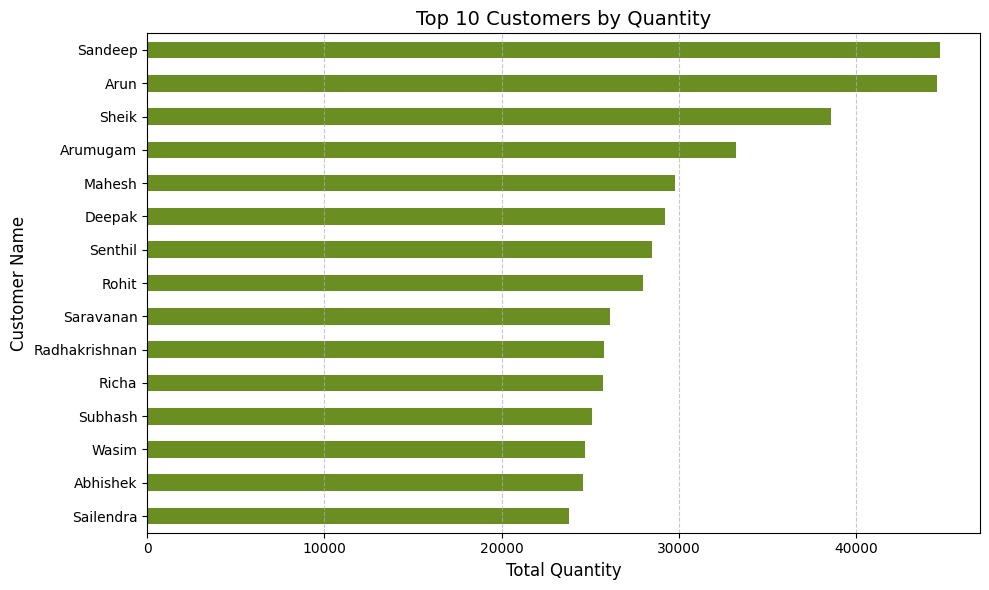

In [48]:
top_n = 15
top_customers_qty = df.groupby('Customer Name')['Qty'].sum().sort_values(ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
top_15_customers.plot(kind='barh', color='olivedrab')
plt.title('Top 10 Customers by Quantity', fontsize=14)
plt.xlabel('Total Quantity', fontsize=12)
plt.ylabel('Customer Name', fontsize=12)

plt.gca().invert_yaxis() # Reverse the order of the y-axis to show the highest spender at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Customer Name
Arun        39
Rajesh      37
Vijay       35
Rahul       34
Abhishek    32
Sanjay      31
John        31
Dr          30
Rohit       29
Manoj       28
Sandeep     28
Anand       27
Ajay        27
Amit        27
Prakash     27
Name: count, dtype: int64




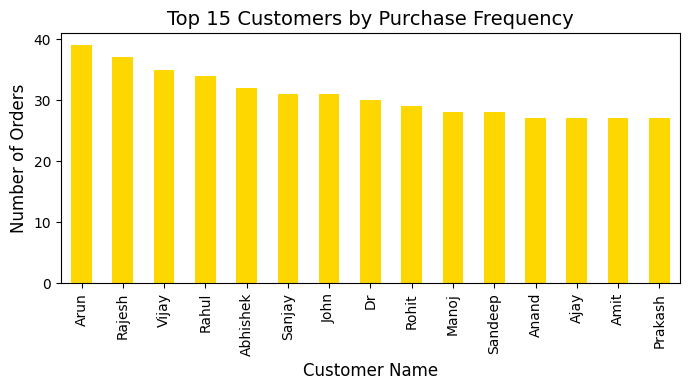

In [49]:
#by purchase frequency

purchase_frequency = df['Customer Name'].value_counts()

top_n1 = 15
top_cust_pf = purchase_frequency.head(top_n1)

print("\n")
top_cust_pf.plot(kind='bar', figsize=(7, 4), color='gold')

plt.title('Top 15 Customers by Purchase Frequency', fontsize=14)
plt.xlabel('Customer Name', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.tight_layout()
plt.show()

In [67]:
print(top_cust_pf)

Customer Name
Arun        39
Rajesh      37
Vijay       35
Rahul       34
Abhishek    32
Sanjay      31
John        31
Dr          30
Rohit       29
Manoj       28
Sandeep     28
Anand       27
Ajay        27
Amit        27
Prakash     27
Name: count, dtype: int64


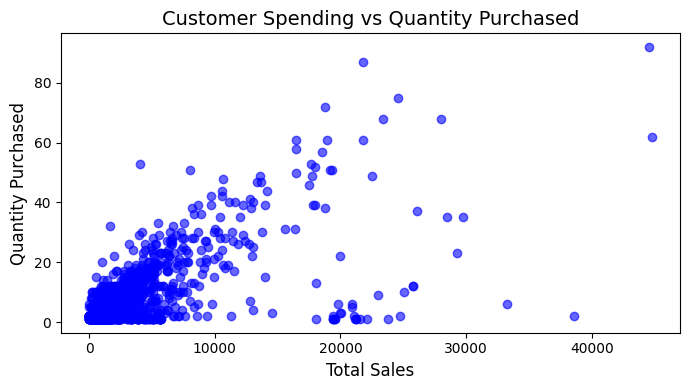

In [50]:
customer_sales = df.groupby('Customer Name')['Total Product Charges'].sum()
customer_quantity = df.groupby('Customer Name')['Qty'].sum()

plt.figure(figsize=(7, 4))
plt.scatter(customer_sales, customer_quantity, alpha=0.6, color='blue')

plt.title('Customer Spending vs Quantity Purchased', fontsize=14)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Quantity Purchased', fontsize=12)
plt.tight_layout()
plt.show()


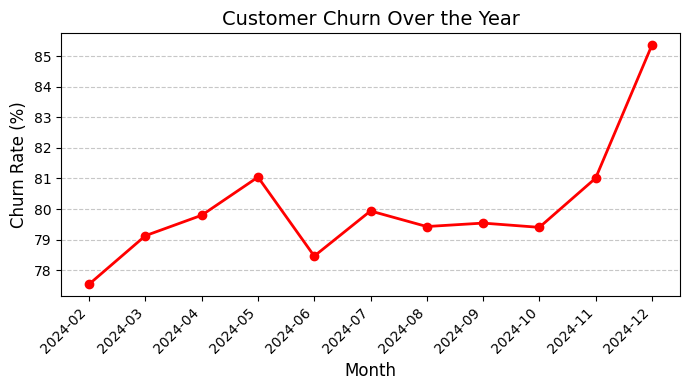

In [51]:
df['Year-Month'] = df['Order Date'].dt.to_period('M')

monthly_customers = df.groupby('Year-Month')['Customer Name'].unique()

churn_rate = []
for i in range(len(monthly_customers)-1):
    current_monthly_customers = set(monthly_customers.iloc[i])
    next_monthly_customers = set(monthly_customers.iloc[i + 1])
    churned_customers = current_monthly_customers - next_monthly_customers
    churn_rate.append(len(churned_customers)/len(current_monthly_customers) * 100 if len(current_monthly_customers) > 0 else 0)

months = [str(month) for month in monthly_customers.index][1:]
churn_data = pd.DataFrame({'Month':months, 'Churn Rate (%)': churn_rate})


plt.figure(figsize=(7, 4))
plt.plot(churn_data['Month'], churn_data['Churn Rate (%)'], marker='o', color='red', linewidth=2)
plt.title('Customer Churn Over the Year', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

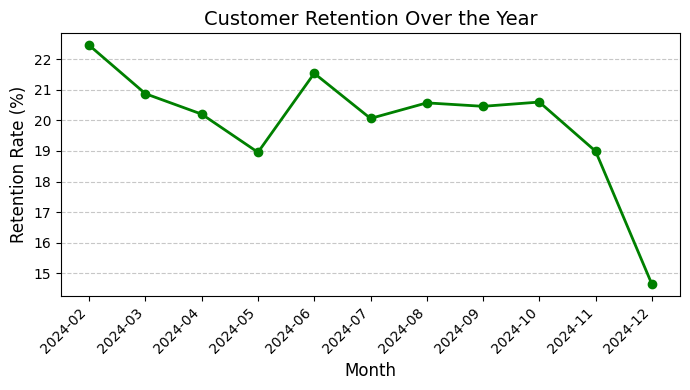

In [52]:
retention_rate = []
for i in range(len(monthly_customers) - 1):
    current_month_customers = set(monthly_customers.iloc[i])
    next_month_customers = set(monthly_customers.iloc[i + 1])
    retained_customers = current_month_customers & next_month_customers 
    retention_rate.append(len(retained_customers) / len(current_month_customers) * 100 if len(current_month_customers) > 0 else 0)

retention_data = pd.DataFrame({'Month': months, 'Retention Rate (%)': retention_rate})

plt.figure(figsize=(7, 4))
plt.plot(retention_data['Month'], retention_data['Retention Rate (%)'], marker='o', color='green', linewidth=2)
plt.title('Customer Retention Over the Year', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Retention Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


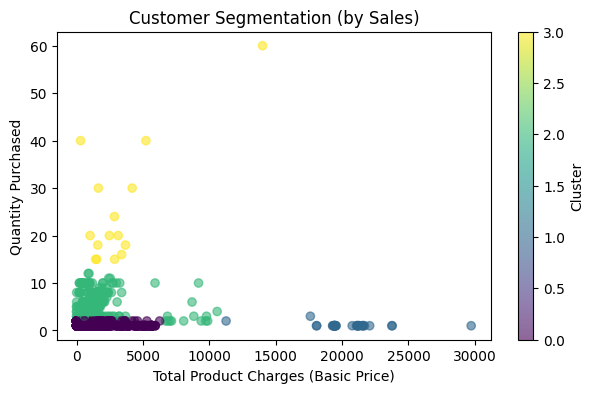

In [52]:
#customer segmentation using k means (sales based)
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

features = ['Total Product Charges', 'Qty']
df['Total Product Charges'] = pd.to_numeric(df['Total Product Charges'],errors = 'coerce')
df['Qty'] = pd.to_numeric(df['Qty'], errors='coerce')

df = df.dropna(subset = features)

scaler = StandardScaler()
X= scaler.fit_transform(df[features])

inertia = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

    # Plotting the elbow curve
# plt.figure(figsize=(7, 4))
# plt.plot(range(1, 11), inertia, marker='o')
# plt.title('Elbow Method for Optimal Clusters')
# plt.xlabel('Number of Clusters')
# plt.ylabel('Inertia')
# plt.show()

optimal_clusters = 4
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# Plot the customer segmentation clusters
fig18 = plt.figure(figsize=(7, 4))
plt.scatter(df['Total Product Charges'], df['Qty'], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.title('Customer Segmentation (by Sales)')
plt.xlabel('Total Product Charges (Basic Price)')
plt.ylabel('Quantity Purchased')
plt.colorbar(label='Cluster')
plt.show()



In [53]:
for cluster in df['cluster'].unique():
    cluster_data = df[df['cluster'] == cluster]
    
    
    if cluster_data['Total Product Charges'].mean() > 1500:
        value_level = 'High-Value'
    elif cluster_data['Total Product Charges'].mean() > 750:
        value_level = 'Moderate-Value'
    else:
        value_level = 'Low-Value'
    
    print(f"{value_level} Customers (Cluster {cluster}):")
    print(f"  Average Total Product Charges: {cluster_data['Total Product Charges'].mean():.2f}")
    print(f"  Average Quantity: {cluster_data['Qty'].mean():.2f}")
    print(f"  Number of Customers: {len(cluster_data)}")
    print()  

Low-Value Customers (Cluster 0):
  Average Total Product Charges: 602.31
  Average Quantity: 1.52
  Number of Customers: 7789

Moderate-Value Customers (Cluster 2):
  Average Total Product Charges: 888.71
  Average Quantity: 4.21
  Number of Customers: 1586

High-Value Customers (Cluster 3):
  Average Total Product Charges: 3285.85
  Average Quantity: 25.40
  Number of Customers: 15

High-Value Customers (Cluster 1):
  Average Total Product Charges: 20321.70
  Average Quantity: 1.09
  Number of Customers: 33



In [54]:
# Iterate through each cluster and print customer details
for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    
    # Determine customer value level
    if cluster_data['Total Product Charges'].mean() > 1500:
        value_level = 'High-Value'
    elif cluster_data['Total Product Charges'].mean() > 750:
        value_level = 'Moderate-Value'
    else:
        value_level = 'Low-Value'
    
    print(f"{value_level} Customers (Cluster {cluster}):")
    print(f"  Average Total Product Charges: {cluster_data['Total Product Charges'].mean():.2f}")
    print(f"  Average Quantity: {cluster_data['Qty'].mean():.2f}")
    print(f"  Number of Customers: {len(cluster_data)}")
    print("  Customers in this cluster:")
    print(cluster_data[['Customer Name', 'Total Product Charges', 'Qty']])  # Display relevant columns
    print("-" * 50)  # Separator between clusters


Low-Value Customers (Cluster 0):
  Average Total Product Charges: 602.31
  Average Quantity: 1.52
  Number of Customers: 7789
  Customers in this cluster:
     Customer Name  Total Product Charges  Qty
0       R. Subbiah                 580.00  2.0
1             Gail                 580.00  2.0
2         Surendra                 290.00  1.0
3            Sudip                 580.00  2.0
4          Brijesh                 290.00  1.0
...            ...                    ...  ...
9417        Aparna                 266.95  1.0
9418         Ameen                1207.63  2.0
9419       Roopesh                 540.68  2.0
9421         Kiran                 591.53  2.0
9422       Jeyaraj                1516.95  1.0

[7789 rows x 3 columns]
--------------------------------------------------
High-Value Customers (Cluster 1):
  Average Total Product Charges: 20321.70
  Average Quantity: 1.09
  Number of Customers: 33
  Customers in this cluster:
        Customer Name  Total Product Charges  Qty

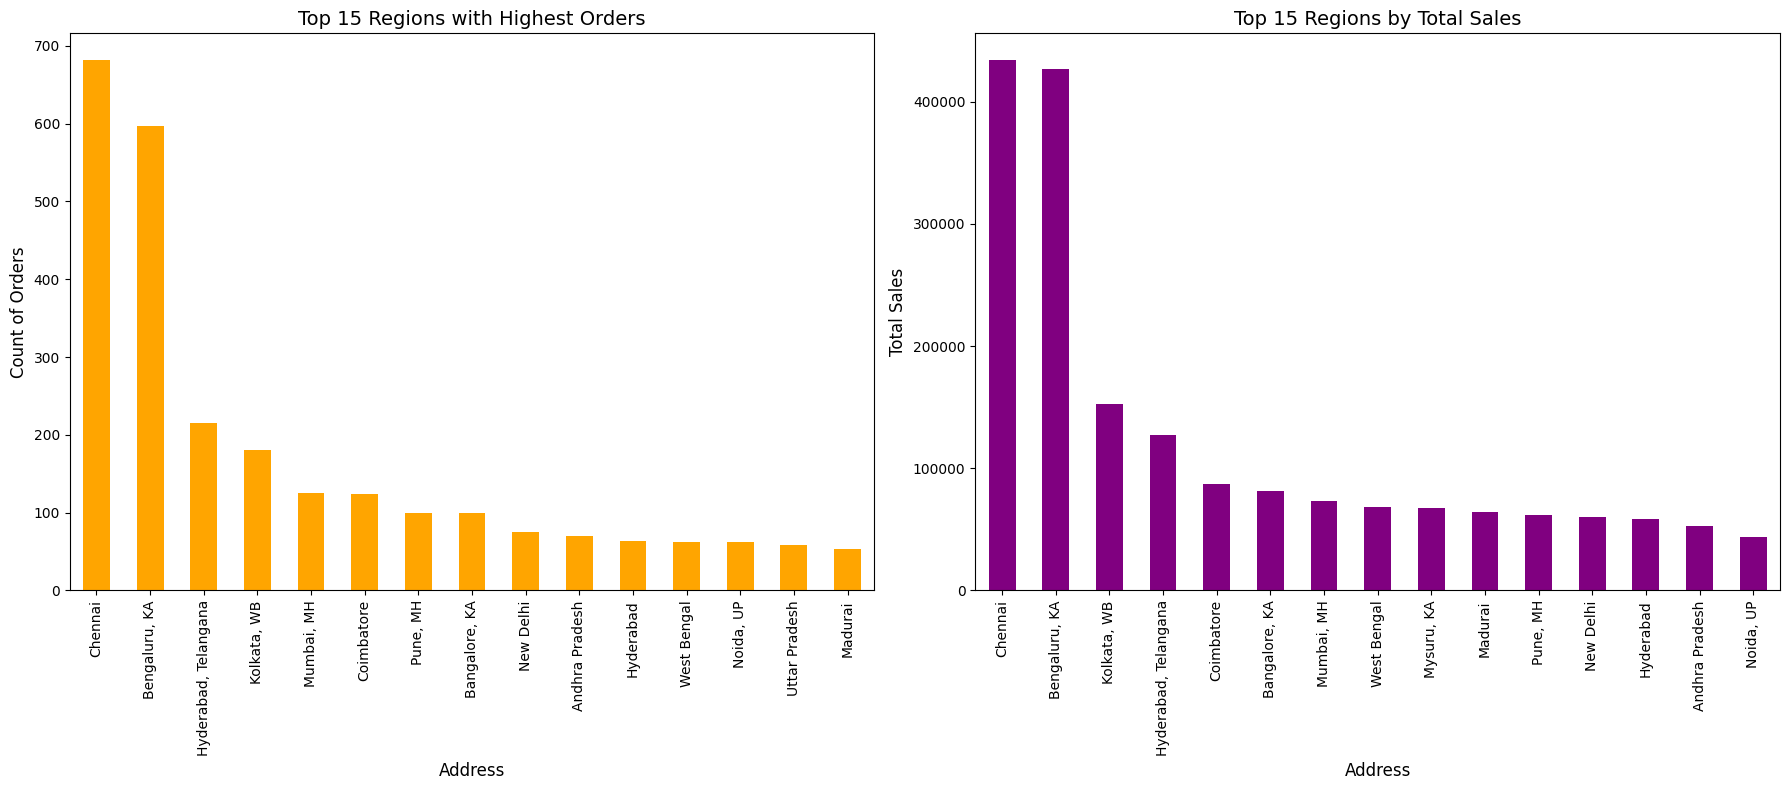

In [55]:
count_by_region = df['Address'].value_counts()

sales_by_region = df.groupby('Address')['Total Product Charges'].sum()

top_n2 = 15
top_region_by_count = count_by_region.head(top_n2)
top_region_by_sales = sales_by_region.sort_values(ascending=False).head(top_n2)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top_region_by_count.plot(kind='bar', ax=axes[0], color='orange')
axes[0].set_title(f'Top {top_n} Regions with Highest Orders', fontsize=14)
axes[0].set_xlabel('Address', fontsize=12)
axes[0].set_ylabel('Count of Orders', fontsize=12)

top_region_by_sales.plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_title(f'Top {top_n} Regions by Total Sales', fontsize=14)
axes[1].set_xlabel('Address', fontsize=12)
axes[1].set_ylabel('Total Sales', fontsize=12)

plt.tight_layout()
plt.show()



In [56]:
print(top_region_by_count)
print(top_region_by_sales)

Address
Chennai                 682
Bengaluru, KA           597
Hyderabad, Telangana    215
Kolkata, WB             180
Mumbai, MH              125
Coimbatore              124
Pune, MH                100
Bangalore, KA            99
New Delhi                75
Andhra Pradesh           70
Hyderabad                64
West Bengal              62
Noida, UP                62
Uttar Pradesh            58
Madurai                  53
Name: count, dtype: int64
Address
Chennai                 434146.22
Bengaluru, KA           426614.85
Kolkata, WB             152349.12
Hyderabad, Telangana    126845.19
Coimbatore               87321.47
Bangalore, KA            81398.76
Mumbai, MH               72830.48
West Bengal              68512.37
Mysuru, KA               67177.40
Madurai                  64231.12
Pune, MH                 61850.17
New Delhi                60457.06
Hyderabad                58565.26
Andhra Pradesh           52845.23
Noida, UP                43487.88
Name: Total Product Charges,

C:\Users\Swathi G\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


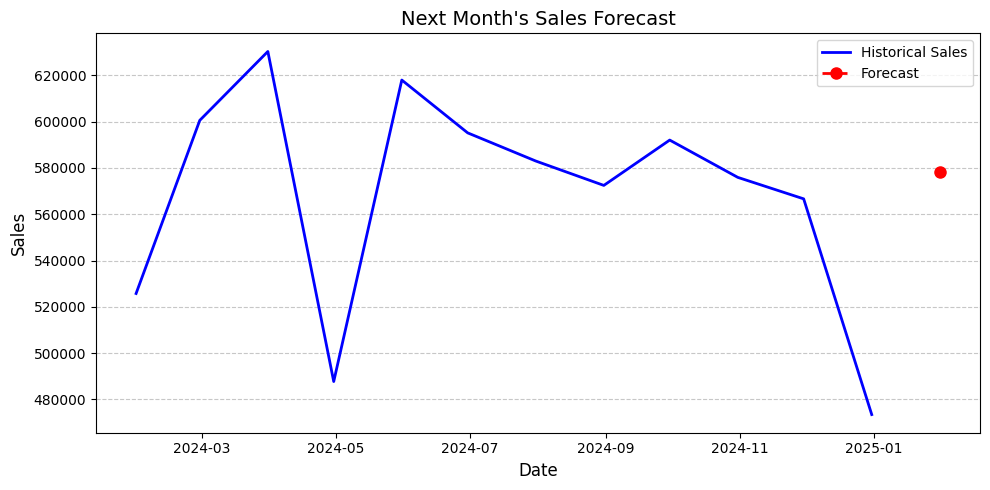

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sales_data = df[['Order Date', 'Total Product Charges']]
sales_data.columns = ['Date', 'Sales']
sales_data['Date'] = pd.to_datetime(sales_data['Date'])

# Set 'Date' as the index
sales_data.set_index('Date', inplace=True)

# Group by month and sum the sales
sales_data = sales_data.resample('M').sum()

# Check the length of the sales data
num_months = len(sales_data)
seasonal_periods = 12 if num_months >= 24 else 6  # Adjust if less than 2 years of data

# Create and fit the model
model = ExponentialSmoothing(sales_data['Sales'], seasonal='add', seasonal_periods=seasonal_periods)
model_fit = model.fit()

# Forecast for the next month
forecast_steps = 1
forecast = model_fit.forecast(forecast_steps)

# Manually set the forecasted date (next month)
forecast_date = sales_data.index[-1] + pd.DateOffset(months=1)

# Plot historical sales and forecast
plt.figure(figsize=(10, 5))
plt.plot(sales_data.index, sales_data['Sales'], label='Historical Sales', color='blue', linewidth=2)
plt.plot(forecast_date, forecast, label='Forecast', color='red', marker='o', markersize=8, linestyle='--', linewidth=2)

# Customize the plot
plt.title('Next Month\'s Sales Forecast', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




C:\Users\Swathi G\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


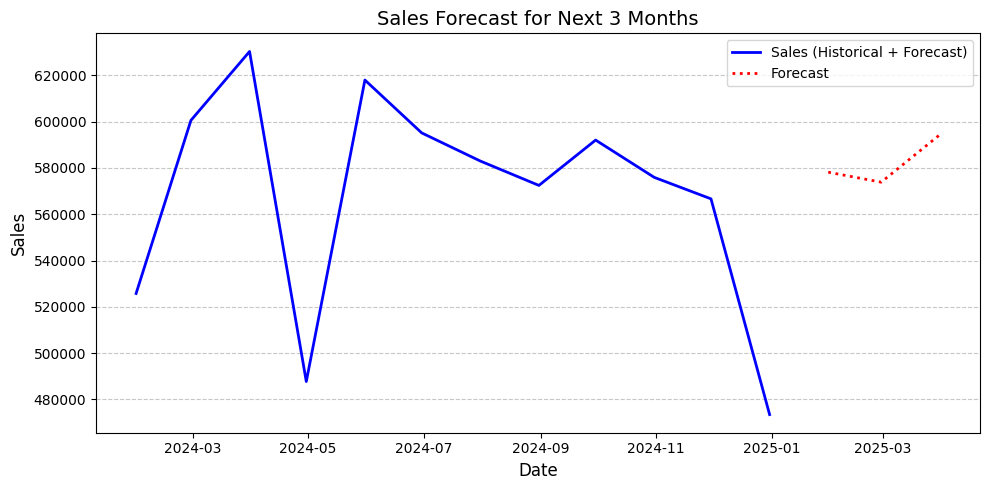

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Assuming df is your dataframe with 'Order Date' and 'Total Product Charges'
sales_data = df[['Order Date', 'Total Product Charges']]
sales_data.columns = ['Date', 'Sales']
sales_data['Date'] = pd.to_datetime(sales_data['Date'])

# Set 'Date' as the index
sales_data.set_index('Date', inplace=True)

# Group by month and sum the sales
sales_data = sales_data.resample('M').sum()

# Check the length of the sales data
num_months = len(sales_data)
seasonal_periods = 12 if num_months >= 24 else 6  # Adjust if less than 2 years of data

# Create and fit the model
model = ExponentialSmoothing(sales_data['Sales'], seasonal='add', seasonal_periods=seasonal_periods)
model_fit = model.fit()

# Forecast for the next 3 months
forecast_steps = 3
forecast = model_fit.forecast(forecast_steps)

# Manually set the forecasted dates (next 3 months)
forecast_dates = pd.date_range(sales_data.index[-1] + pd.DateOffset(months=1), periods=3, freq='M')

# Create a new series for the forecasted values
forecast_series = pd.Series(forecast.values, index=forecast_dates)

# Concatenate the historical sales with the forecasted sales to plot them together
combined_data = pd.concat([sales_data, forecast_series])

# Plot historical sales and forecast as a continuation
plt.figure(figsize=(10, 5))
plt.plot(combined_data.index, combined_data['Sales'], label='Sales (Historical + Forecast)', color='blue', linewidth=2)

# Highlight the forecasted part with a dotted line
plt.plot(forecast_series.index, forecast_series.values, label='Forecast', color='red', linestyle=':', linewidth=2)

# Customize the plot
plt.title('Sales Forecast for Next 3 Months', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# # Print the forecasted sales for the next 3 months
# print("Forecasted Sales for Next 3 Months:")
# for date, value in zip(forecast_series.index, forecast_series.values):
#     print(f"{date.strftime('%B %Y')}: {value:.2f}")


C:\Users\Swathi G\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


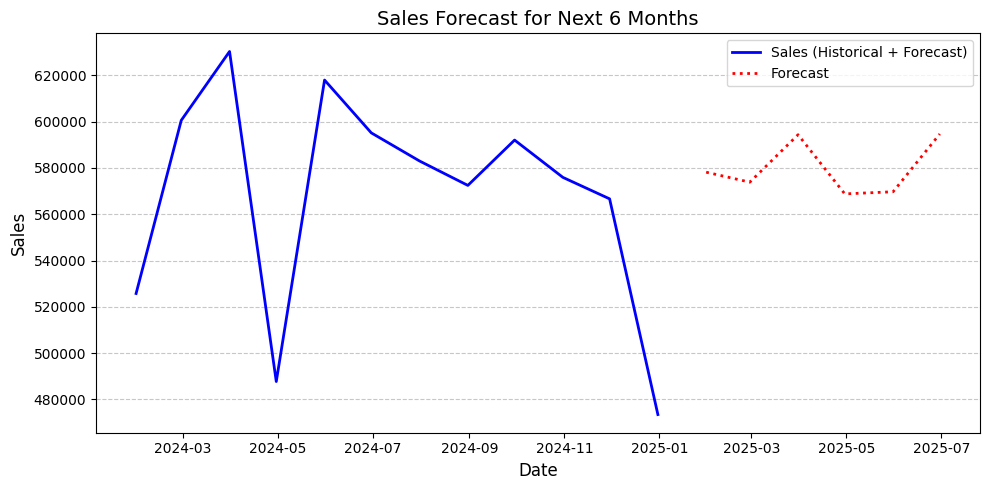

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Assuming df is your dataframe with 'Order Date' and 'Total Product Charges'
sales_data = df[['Order Date', 'Total Product Charges']]
sales_data.columns = ['Date', 'Sales']
sales_data['Date'] = pd.to_datetime(sales_data['Date'])

# Set 'Date' as the index
sales_data.set_index('Date', inplace=True)

# Group by month and sum the sales
sales_data = sales_data.resample('M').sum()

# Check the length of the sales data
num_months = len(sales_data)
seasonal_periods = 12 if num_months >= 24 else 6  # Adjust if less than 2 years of data

# Create and fit the model
model = ExponentialSmoothing(sales_data['Sales'], seasonal='add', seasonal_periods=seasonal_periods)
model_fit = model.fit()

# Forecast for the next 6 months
forecast_steps = 6
forecast = model_fit.forecast(forecast_steps)

# Manually set the forecasted dates (next 6 months)
forecast_dates = pd.date_range(sales_data.index[-1] + pd.DateOffset(months=1), periods=6, freq='M')

# Create a new series for the forecasted values
forecast_series = pd.Series(forecast.values, index=forecast_dates)

# Concatenate the historical sales with the forecasted sales to plot them together
combined_data = pd.concat([sales_data, forecast_series])

# Plot historical sales and forecast as a continuation
plt.figure(figsize=(10, 5))
plt.plot(combined_data.index, combined_data['Sales'], label='Sales (Historical + Forecast)', color='blue', linewidth=2)

# Highlight the forecasted part with a dotted line
plt.plot(forecast_series.index, forecast_series.values, label='Forecast', color='red', linestyle=':', linewidth=2)

# Customize the plot
plt.title('Sales Forecast for Next 6 Months', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [60]:

# Print the forecasted sales for the next 6 months
print("Forecasted Sales for Next 6 Months:")
for date, value in zip(forecast_series.index, forecast_series.values):
    print(f"{date.strftime('%B %Y')}: {value:.2f}")

Forecasted Sales for Next 6 Months:
January 2025: 578140.26
February 2025: 573832.16
March 2025: 594312.47
April 2025: 568768.34
May 2025: 569695.15
June 2025: 594644.67


In [61]:
import pandas as pd
import re

def standardize_product_names(df):
    """
    Standardizes product names in a DataFrame by grouping similar names 
    and removing quantities, units, and other unwanted elements.
    """
    # List of predefined variations for product names
    variations = [
        ["gloss and glow", "glow gloss", "glow and gloss", "gloss, glow, flash", "gloss, glow and flash", "glow - 6 nos"],
        ["24mm aerator", "24mm aerator 28mm aerator", "24mm aerator - 3 nos", "24mm aerator - 5 nos 28mm aerator - 4 nos", "24mm aerator 2 nos", "shower arm 12 inch 24mm aerator", "rapidclean and 24mm aerator 2 nos", "aerator big", "aerator big - 2 nos"],
        ["28mm aerator", "28mm aerator", "28mm aerator - 4 nos"],
        ["38mm knob assembly", "38 mm knob assembly", "38 mm knob assembly - 2 nos", "38mm knob assembly - 2 nos solid sc hinges", "38mm knob assembly and slimline outlet assembly washer", "48 mm knob assembly and 38 mm knob assembly"],
        ["48mm knob assembly", "48 mm knob assembly"],
        ["58mm knob assembly", "single outlet assembly 10 inches and 58mm knob assembly", "58 mm knob assembly", "58mm knob assembly single piece outlet assembly 10 inches", "58 mm pe knob assembly", "58 mm round pe", "58 mm round pe - 2 nos"],
        ["aquasoft 12", "aquasoft 12 and 16", "aquasoft - 12", "aquasoft 12 ", "aquasoft 12 - 1 no", "aquasoft 16 and aquasoft 12", "aquasoft 16 aquasoft 12"],
        ["aquasoft 16", "aqusoft 16", "aquasoft - 16", "aquasoft 16 ", "aquasoft 16 - 1 no", "aquasoft 16 - 2 nos", "aquasot 16"],
        ["aquasoft 30", "aquasoft 30 - 1 no"],
        ["aquasoft 110"],
        ["aquasoft 70"],
        ["aurafresh scented drain mat adf", "aurafresh adf drain mat with refill free", "aurafresh drain mat - 10 nos", "aurafresh drain mat - 5 nos refill free", "aurafresh drain mat adf ", "aurafresh scented drain mat - 10 nos", "aurafresh scent"],
        ["casa soft close seat cover", "casa soft close seat cover hinges"],
        ["cascade inlet assembly", "cascade inlet and outlet assembly"],
        ["cascade outlet assembly", "cascade outet assembly"],
        ["claret two way angle valve"],
        ["comfort ewc seat cover"],
        ["coral neo health faucet"],
        ["durasheen soft close seat cover"],
        ["flash"],
        ["floorclean adf 5l", "floorclean passion 5l"],
        ["floorclean sl 5l"],
        ["gasket for outlet assembly"],
        ["gloss", "glow", "glow and flash"],
        ["inner head standard"],
        ["inner head quarter turn"],
        ["jade bib cock"],
        ["jade inner head"],
        ["jade knob assembly"],
        ["jade sink cock"],
        ["jade wall mixer 2 in 1"],
        ["jade wall mixer 3 in 1"],
        ["linea plus concealed cistern with half frame"],
        ["linea plus concealed cistern without frame"],
        ["linea plus push plate round"],
        ["linea plus push plate square"],
        ["ptfe tape"],
        ["pluto overhead shower"],
        ["pruno bib cock"],
        ["rapidclean"],
        ["roca victoria seat cover"],
        ["sanclean", "sanclean pro"],
        ["shower arm 12 inch"],
        ["single flow hand shower"],
        ["single outlet assembly 10 inches"],
        ["single piece inlet valve"],
        ["single piece outlet assembly 8 inches"],
        ["slimline arm economy"],
        ["slimline bend pipe and bung washer and slimline outlet assembly washer"],
        ["alpha shower head"],
        ["atlantis shower panel"],
        ["aerator big", "aerator small"]
    ]

    def clean_product_name(product):
        """Cleans the product name by removing quantities, units, and special characters."""
        if pd.isnull(product):
            return product  # Return NaN if the product is missing
        product = product.lower()  # Case-insensitive
        # Remove quantities and units (e.g., "5 nos", "10 pieces")
        product = re.sub(r'\b\d+\s*(nos|pieces|g|kg|ml|liters|units|set|no)?\b', '', product)
        # Remove special characters and extra spaces
        product = re.sub(r'[^\w\s]', '', product)
        product = re.sub(r'\s+', ' ', product).strip()
        return product

    def get_standardized_name(product):
        """Returns a standardized product name based on the variations list."""
        product_cleaned = clean_product_name(product)
        if pd.isnull(product_cleaned):
            return product_cleaned  # Return NaN if the product is missing
        for standard_variations in variations:
            standard = standard_variations[0]
            if product_cleaned in standard_variations:
                return standard
        return product_cleaned

    # Apply the function to the 'Products' column
    df['Standardized_Products'] = df['Products'].apply(get_standardized_name)
    return df

df = standardize_product_names(df)
print(df[['Products', 'Standardized_Products']])


                                 Products                Standardized_Products
0                       Smartflush Citrus                    smartflush citrus
1                       Smartflush Citrus                    smartflush citrus
2                     Smartflush CitrusNo                  smartflush citrusno
3                       Smartflush Citrus                    smartflush citrus
4                     Smartflush CitrusNo                  smartflush citrusno
...                                   ...                                  ...
9418    Cascade Inlet and Outlet Assembly               cascade inlet assembly
9419                      Smartflush Aqua                      smartflush aqua
9420                  Slimline Syphon Set                  slimline syphon set
9421           Smartflush Citrus and Aqua           smartflush citrus and aqua
9422  Slimline Premium DF Polymer Cistern  slimline premium df polymer cistern

[9423 rows x 2 columns]


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure 'Order Date' is in datetime format
if 'Order Date' not in df.columns or 'Standardized_Products' not in df.columns:
    raise KeyError("Required columns 'Order Date' or 'Standardized_Products' are missing in the dataset.")

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df.dropna(subset=['Order Date'], inplace=True)  # Drop rows with invalid dates

# Group data by product and order date
product_demand = df.groupby(['Standardized_Products', 'Order Date'])['Qty'].sum().reset_index()

# Display available products
available_products = product_demand['Standardized_Products'].str.lower().unique()
print("Available products:")
for product in available_products:
    print(f"- {product}")

# Function to forecast demand for a specified product
def forecast_demand(product_name, product_demand, steps=60):
    product_name = product_name.lower()

    # Filter data for the specified product
    product_data = product_demand[product_demand['Standardized_Products'].str.lower() == product_name]

    if product_data.empty:
        print(f"No data available for product: {product_name}")
        return

    product_data = product_data.set_index('Order Date')
    product_data = product_data.resample('D').sum().fillna(0)

    # Check if there's enough data to fit a model
    if len(product_data) < 10:
        print(f"Not enough data to forecast for product: {product_name}")
        return

    # Fit SARIMA model (Seasonal ARIMA to capture seasonality)
    model = SARIMAX(product_data['Qty'], 
                    order=(5, 1, 0),
                    seasonal_order=(1, 1, 1, 7),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    
    model_fit = model.fit(disp=False)

    # Forecast next `steps` days
    forecast = model_fit.forecast(steps=steps)

    # Plot historical data and forecast
    plt.figure(figsize=(12, 6))
    plt.plot(product_data['Qty'], label="Historical Data")
    plt.plot(pd.date_range(product_data.index[-1], periods=steps+1, freq='D')[1:], forecast, label="Forecast", color='red')
    plt.title(f"Demand Forecast for {product_name.capitalize()} (Next 3 Months)")
    plt.xlabel("Date")
    plt.ylabel("Quantity Sold")
    plt.legend()
    plt.grid()
    plt.show()

# Prompt the user to specify a product
specified_product = input("\nEnter the product name you want to forecast: ").strip().lower()

# Validate the product input
if specified_product not in available_products:
    print(f"Error: '{specified_product}' is not in the list of available products.")
else:
    forecast_demand(specified_product, product_demand)


Available products:
- 24mm aerator
- 28mm aerator
- 38mm knob assembly
- 38mm knob assembly solid sc hinges
- 48mm knob assembly
- 58mm knob assembly
- aeator big
- aeator small
- aerator big
- alpha shower head
- aquasoft
- aquasoft and
- aquasoft and aquasoft
- aquasoft aquasoft
- aquasot
- aqusoft
- atlantis shower panel
- aurafresh drain mat
- aurafresh drain mat adf
- aurafresh drain mat refill free
- aurafresh drain mat refill freeset
- aurafresh drain mat with refill free
- aurafresh scented drain mat
- aurafresh scented drain mat adf
- aurafresh scented drain mat nossets
- aurafresh scented mat
- aurafresh scented mat pack of
- brissa air freshene blocks
- brissa air freshener
- brissa air freshener combo
- brissa air freshener pack of
- brissa air freshener pack of 4sets
- brissa air freshener tablet
- brissa air freshener tablets
- brissa air fresheners
- brissa pack of
- brissa tablets
- cacade outlet assembly
- casa seat cover
- casa soft close seat
- casa soft close seat c


Enter the product name you want to forecast:  gls


Error: 'gls' is not in the list of available products.


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure 'Order Date' is in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df.dropna(subset=['Order Date'], inplace=True)

# Group data by product and order date
product_demand = df.groupby(['Standardized_Products', 'Order Date'])['Qty'].sum().reset_index()

# Function to forecast demand
def forecast_demand(product_name, product_demand, steps=60):
    product_name = product_name.lower()
    product_data = product_demand[product_demand['Standardized_Products'].str.lower() == product_name]

    if product_data.empty:
        print(f"No data available for product: {product_name}")
        return

    product_data = product_data.set_index('Order Date')
    product_data = product_data.resample('W').sum().fillna(0)  # Aggregate to weekly

    if len(product_data) < 10:
        print(f"Not enough data to forecast for product: {product_name}")
        return

    model = SARIMAX(product_data['Qty'], 
                    order=(2, 1, 2), 
                    seasonal_order=(1, 1, 1, 52), 
                    enforce_stationarity=False, 
                    enforce_invertibility=False)

    model_fit = model.fit(disp=False)
    forecast = model_fit.forecast(steps=steps)

        # Evaluate accuracy using the last `steps` weeks of actual data
    actual = product_data['Qty'][-steps:]
    predicted = forecast[:len(actual)]

    # Calculate accuracy metrics
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    # Print accuracy metrics
    print(f"\nAccuracy Metrics for {product_name.capitalize()}:")
    print(f"- Mean Absolute Error (MAE): {mae:.2f}")
    print(f"- Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"- Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

#     plt.figure(figsize=(12, 6))
#     plt.plot(product_data['Qty'], label="Historical Data")
#     plt.plot(pd.date_range(product_data.index[-1], periods=steps+1, freq='W')[1:], forecast, label="Forecast", color='red')
#     plt.title(f"Demand Forecast for {product_name.capitalize()} (Next 3 Months)")
#     plt.xlabel("Date")
#     plt.ylabel("Quantity Sold")
#     plt.legend()
#     plt.grid()
#     plt.show()

# # Specify product name
# specified_product = input("\nEnter the product name you want to forecast: ").strip().lower()
# available_products = product_demand['Standardized_Products'].str.lower().unique()

# if specified_product not in available_products:
#     print(f"Error: '{specified_product}' is not in the list of available products.")
# else:
#     forecast_demand(specified_product, product_demand)


In [69]:
    # Evaluate accuracy using the last `steps` weeks of actual data
    actual = product_data['Qty'][-steps:]
    predicted = forecast[:len(actual)]

    # Calculate accuracy metrics
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    # Print accuracy metrics
    print(f"\nAccuracy Metrics for {product_name.capitalize()}:")
    print(f"- Mean Absolute Error (MAE): {mae:.2f}")
    print(f"- Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"- Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

NameError: name 'product_data' is not defined


Enter the product name you want to forecast:  gloss



Accuracy Metrics for Gloss:
- Mean Absolute Error (MAE): 107.69
- Root Mean Squared Error (RMSE): 133.67
- Mean Absolute Percentage Error (MAPE): nan%


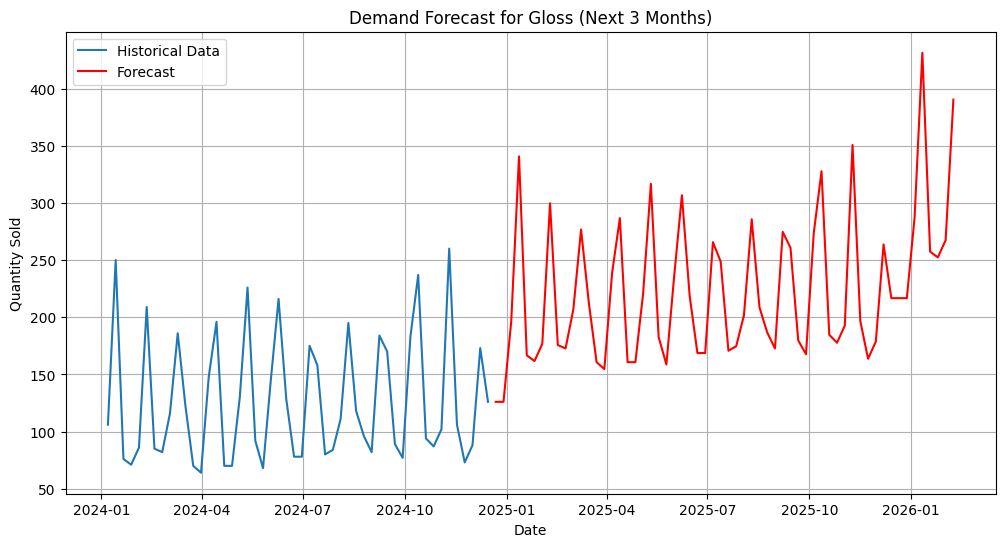

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ensure 'Order Date' is in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df.dropna(subset=['Order Date'], inplace=True)

# Group data by product and order date
product_demand = df.groupby(['Standardized_Products', 'Order Date'])['Qty'].sum().reset_index()

# Function to forecast demand and calculate accuracy metrics
def forecast_demand(product_name, product_demand, steps=60):
    product_name = product_name.lower()
    product_data = product_demand[product_demand['Standardized_Products'].str.lower() == product_name]

    if product_data.empty:
        print(f"No data available for product: {product_name}")
        return

    product_data = product_data.set_index('Order Date')
    product_data = product_data.resample('W').sum().fillna(0)  # Aggregate to weekly

    if len(product_data) < 10:
        print(f"Not enough data to forecast for product: {product_name}")
        return

    # Train SARIMA model
    model = SARIMAX(product_data['Qty'], 
                    order=(2, 1, 2), 
                    seasonal_order=(1, 1, 1, 52), 
                    enforce_stationarity=False, 
                    enforce_invertibility=False)

    model_fit = model.fit(disp=False)

    # Forecast next `steps` weeks
    forecast = model_fit.forecast(steps=steps)

    # Evaluate accuracy using the last `steps` weeks of actual data
    actual = product_data['Qty'][-steps:]
    predicted = forecast[:len(actual)]

    # Calculate accuracy metrics
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    # Print accuracy metrics
    print(f"\nAccuracy Metrics for {product_name.capitalize()}:")
    print(f"- Mean Absolute Error (MAE): {mae:.2f}")
    print(f"- Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"- Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

    # Plot historical data and forecast
    plt.figure(figsize=(12, 6))
    plt.plot(product_data['Qty'], label="Historical Data")
    plt.plot(pd.date_range(product_data.index[-1], periods=steps+1, freq='W')[1:], forecast, label="Forecast", color='red')
    plt.title(f"Demand Forecast for {product_name.capitalize()} (Next 3 Months)")
    plt.xlabel("Date")
    plt.ylabel("Quantity Sold")
    plt.legend()
    plt.grid()
    plt.show()

# Specify product name
specified_product = input("\nEnter the product name you want to forecast: ").strip().lower()
available_products = product_demand['Standardized_Products'].str.lower().unique()

if specified_product not in available_products:
    print(f"Error: '{specified_product}' is not in the list of available products.")
else:
    forecast_demand(specified_product, product_demand)
